FOOD PRICE FORECASTING — EXPLORATORY DATA ANALYSIS

DATASET LOADED
------------------------------------------------------------------------------------------
Path:       d:\OneDrive\Documents\Desktop\Resume Projects\Food Price Forecasting\data\processed\agmarknet_cleaned_observations.csv
Rows:       484,504
Columns:    15
Date range: 2015-01-01 → 2025-12-08
Current cleaned schema: 15 columns
Price units present: ['Rs./Quintal']

BASIC VALIDATION
------------------------------------------------------------------------------------------
Missing expected columns: []
Exact duplicate rows:      0
Duplicate observation keys: 0

Missing values:
Date                      0
Crop                      0
Commodity ID              0
Commodity Group ID        0
State                     0
State ID                  0
Market                    0
Market ID                 0
Variety                   0
Grade                     0
Minimum Price          7339
Maximum Price          7271
Modal Price       

C:\Users\acer\AppData\Local\Temp\ipykernel_3060\2841277912.py:205: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  print(crop_summary.round(2))



CROP COVERAGE FOR EDA
         Crop  Observed_2015_2025_Months  Expected_2015_2025_Months  Missing_2015_2025_Months  Complete_2015_2025
       Banana                        132                        132                         0                True
       Cotton                        132                        132                         0                True
    Groundnut                        132                        132                         0                True
Jowar/Sorghum                        132                        132                         0                True
       Lentil                         22                        132                       110               False
        Maize                        132                        132                         0                True
        Onion                        132                        132                         0                True
       Potato                        132                        1

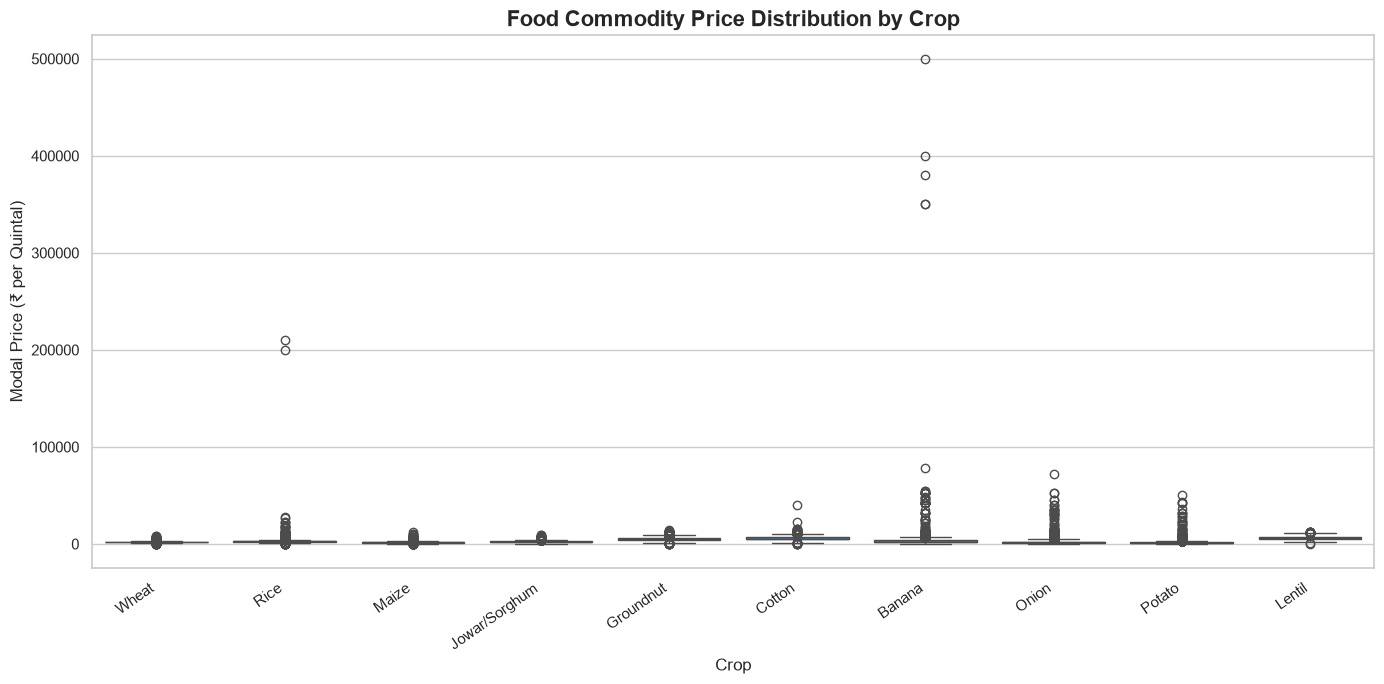

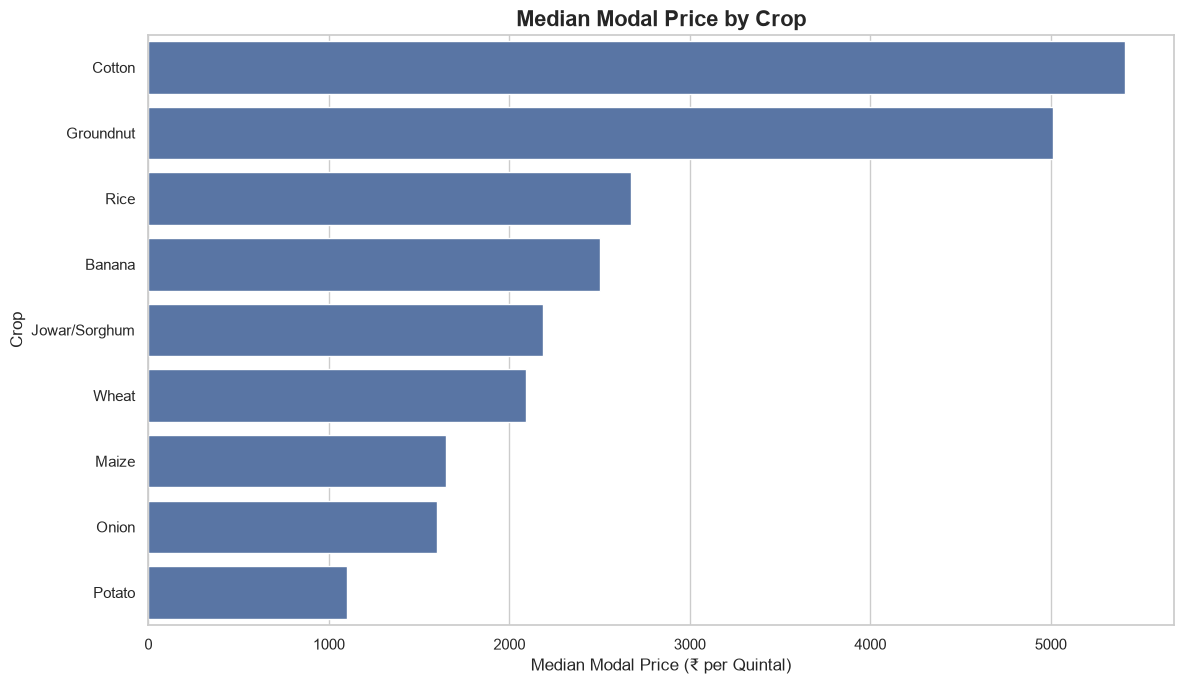

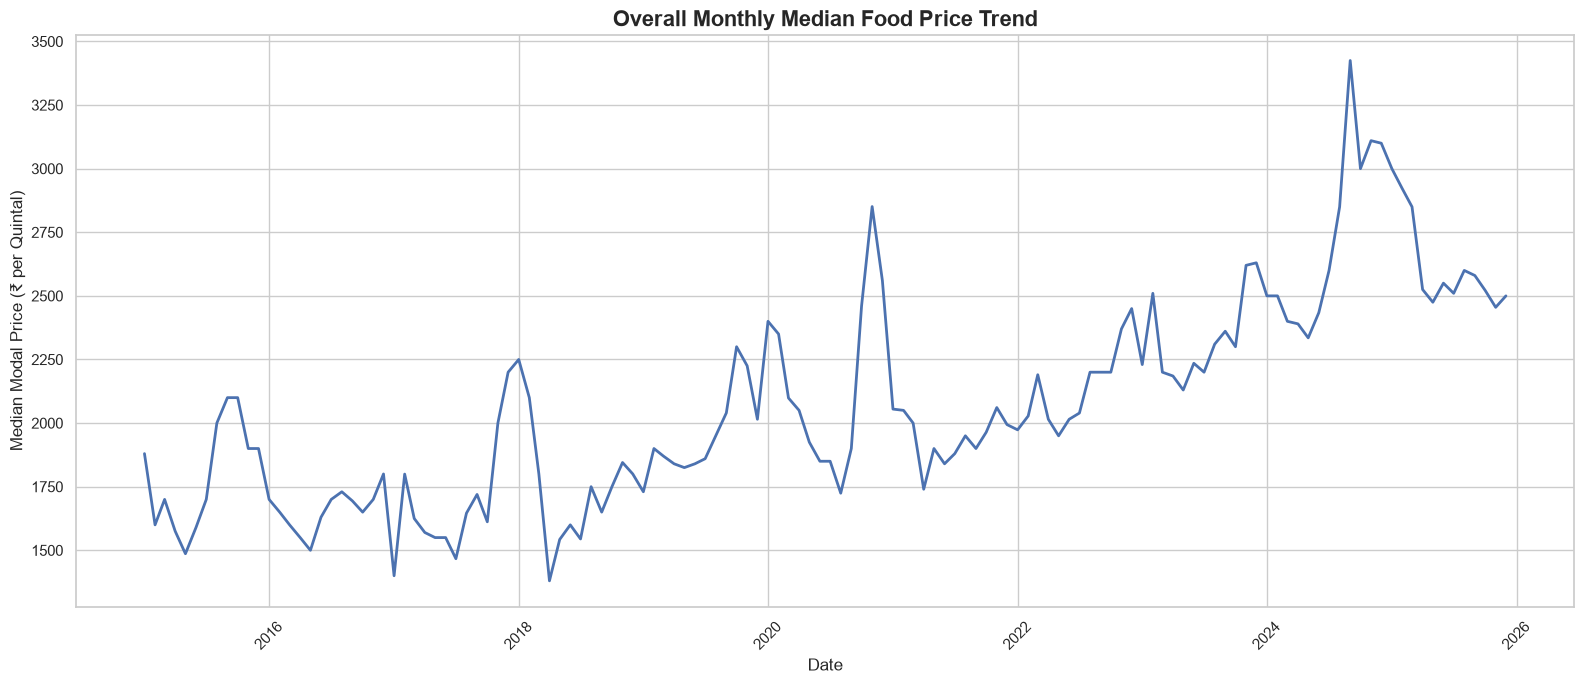

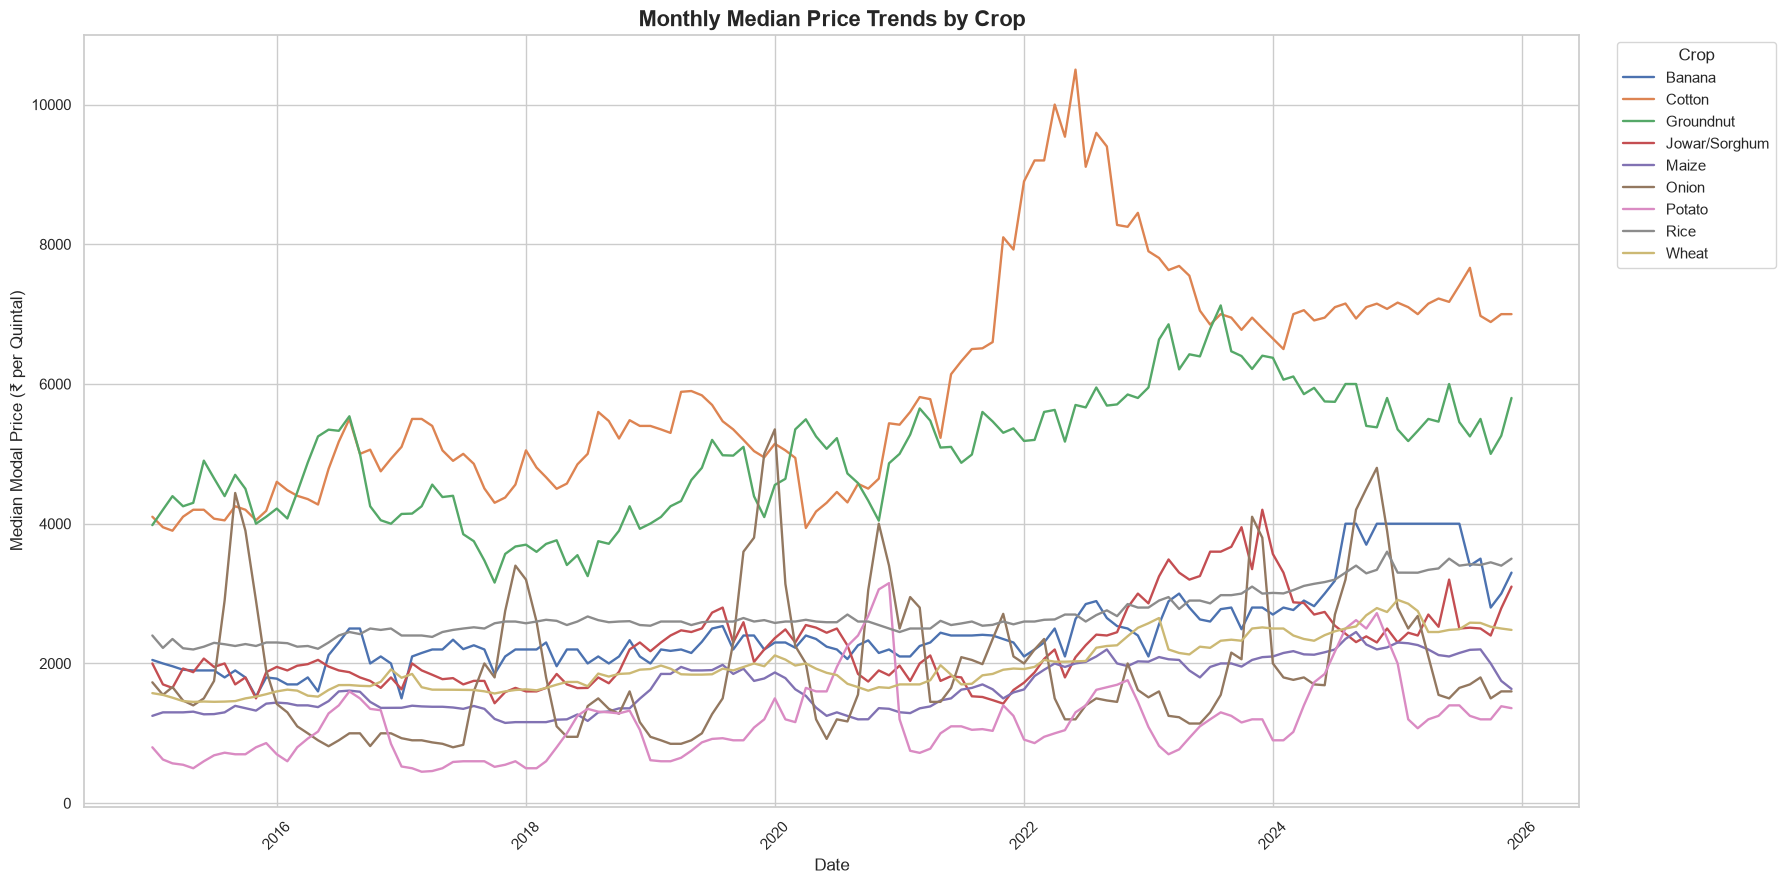

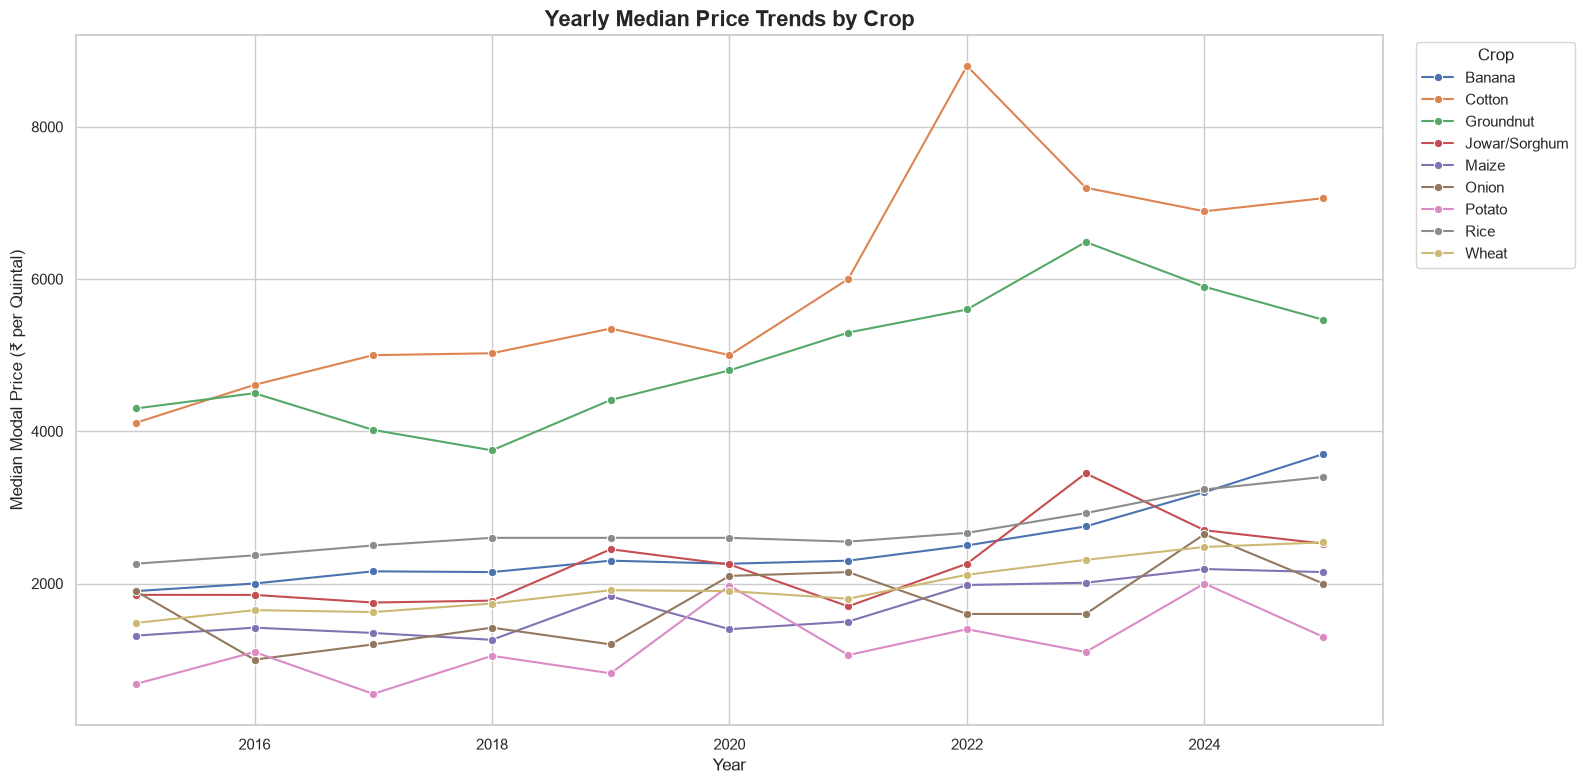

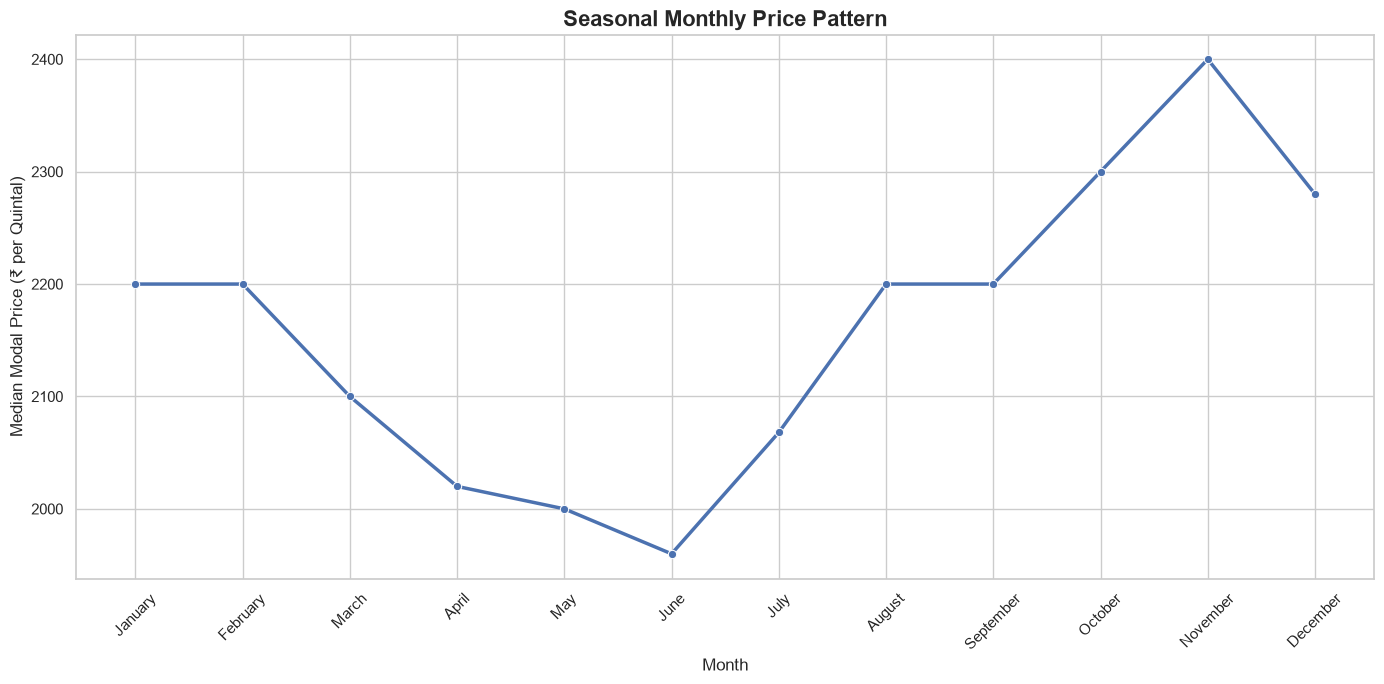

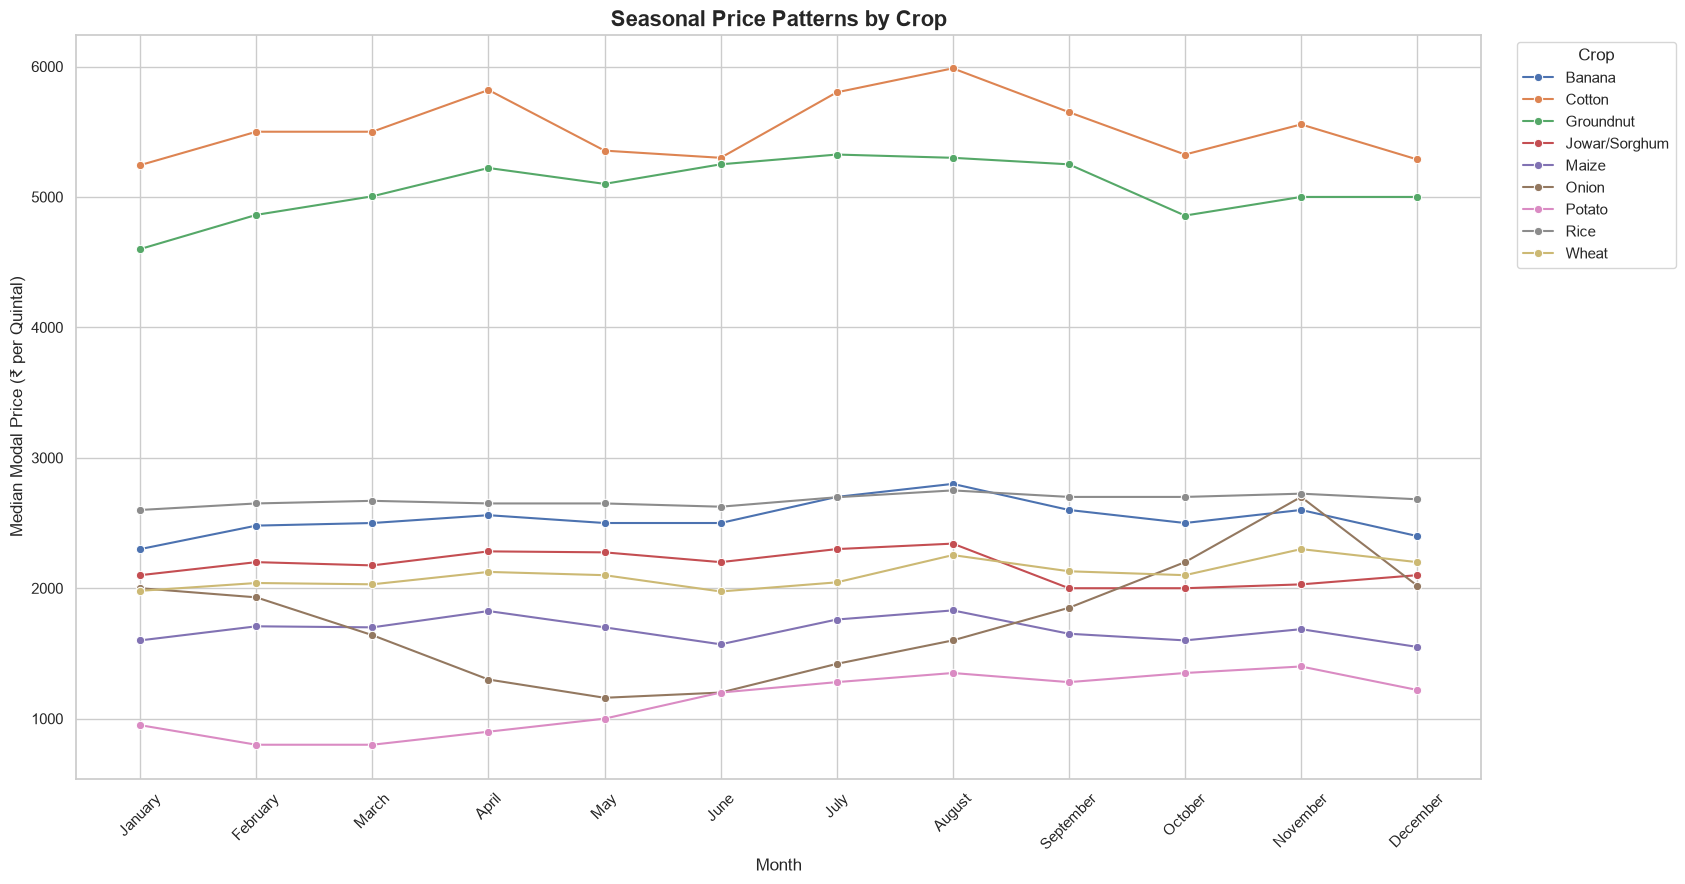


PRICE VOLATILITY BY CROP
                   Mean       Std  Median    Min       Max  Coefficient_of_Variation
Crop                                                                                
Banana         2996.844  3767.220  2500.0    8.0  500000.0                     1.257
Potato         1409.967  1133.382  1100.0    5.0   50000.0                     0.804
Onion          2015.040  1426.681  1600.0    7.0   72000.0                     0.708
Rice           2897.434  1493.342  2675.0    2.0  210000.0                     0.515
Jowar/Sorghum  2363.415   928.022  2185.0  160.5    9000.0                     0.393
Maize          1718.588   483.089  1650.0   30.0   12092.0                     0.281
Groundnut      5192.979  1415.117  5012.0    4.0   14401.0                     0.273
Cotton         5858.601  1576.338  5412.0   54.6   40000.0                     0.269
Wheat          2131.073   443.947  2090.0    1.0    8700.0                     0.208


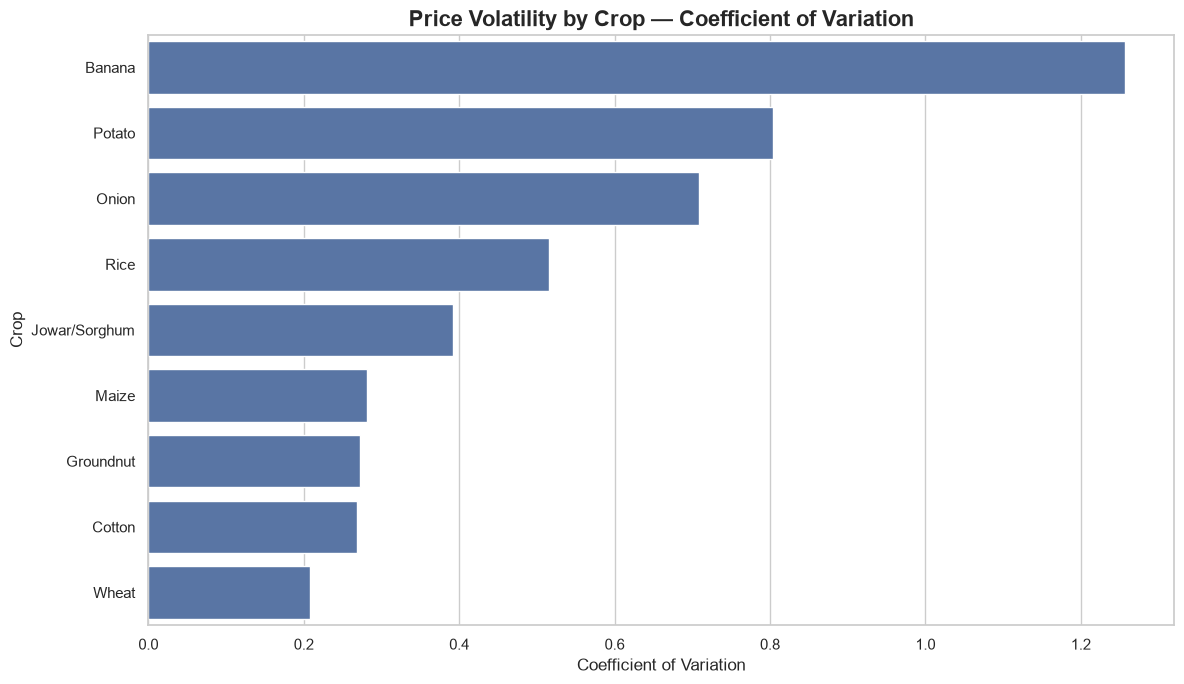

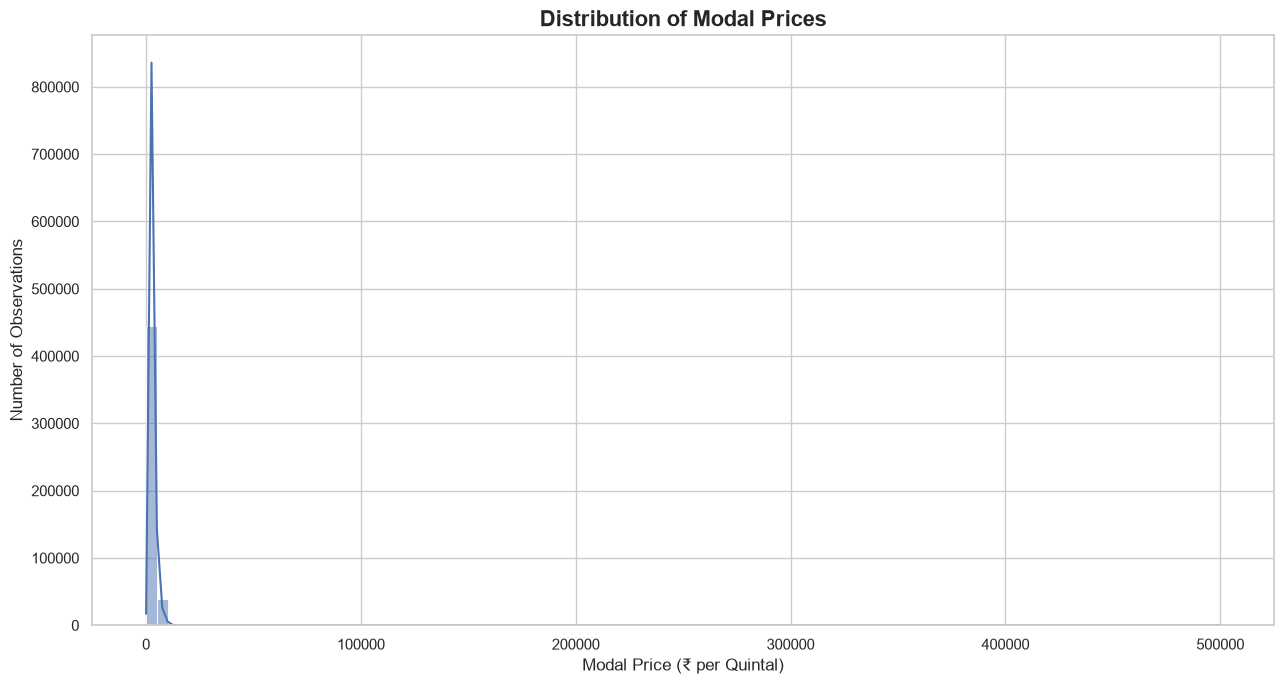

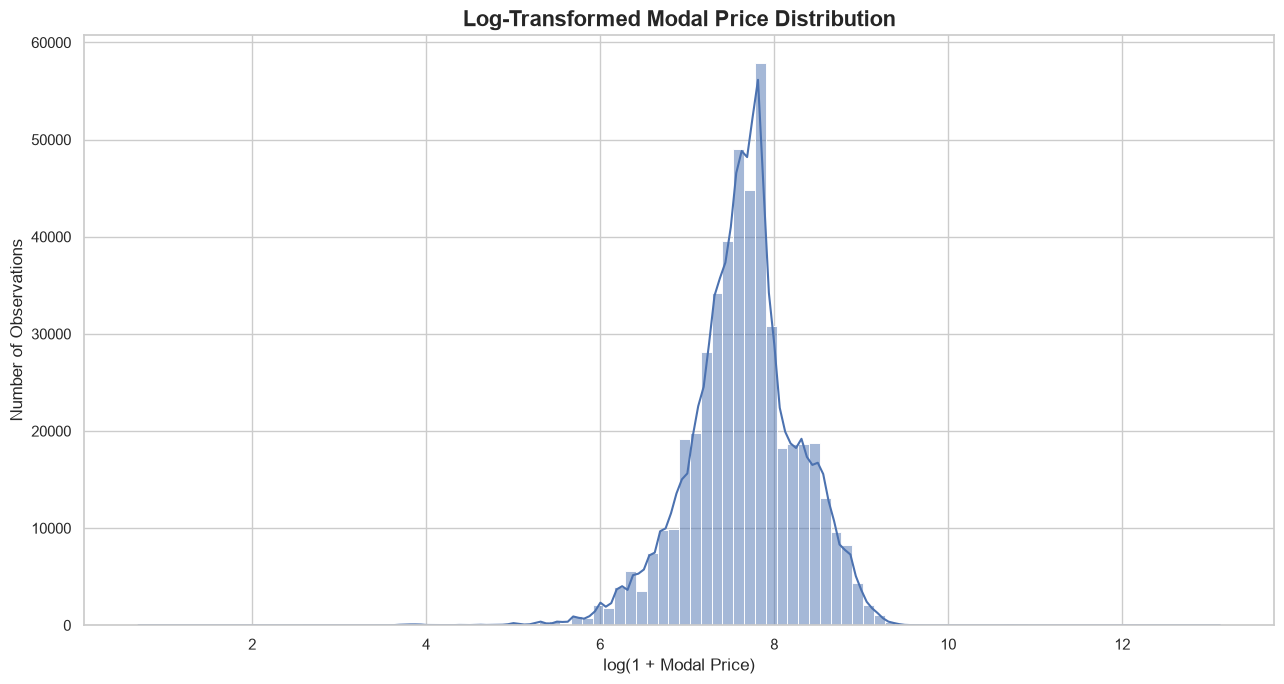


TOP STATES BY OBSERVATION COUNT
                   Observations  Markets  Crops  Median_Price  Mean_Price
State                                                                    
Uttar Pradesh            109579      241     10        2000.0     1986.29
Madhya Pradesh            50682      333     10        1975.0     2187.40
Maharashtra               43737      348     10        2000.0     2418.94
Keralam                   43690      279      7        3400.0     3662.07
Gujarat                   34185      214      9        2595.0     3279.21
West Bengal               33837       77      8        2440.0     2458.33
Punjab                    26542      223      9        1500.0     1708.29
Rajasthan                 24738      186     10        2013.0     2565.80
Karnataka                 19955      148      9        2200.0     2714.37
Haryana                   19949      126     10        1600.0     1982.58
Tamil Nadu                15119      319      8        4623.0     4728.34
Odish

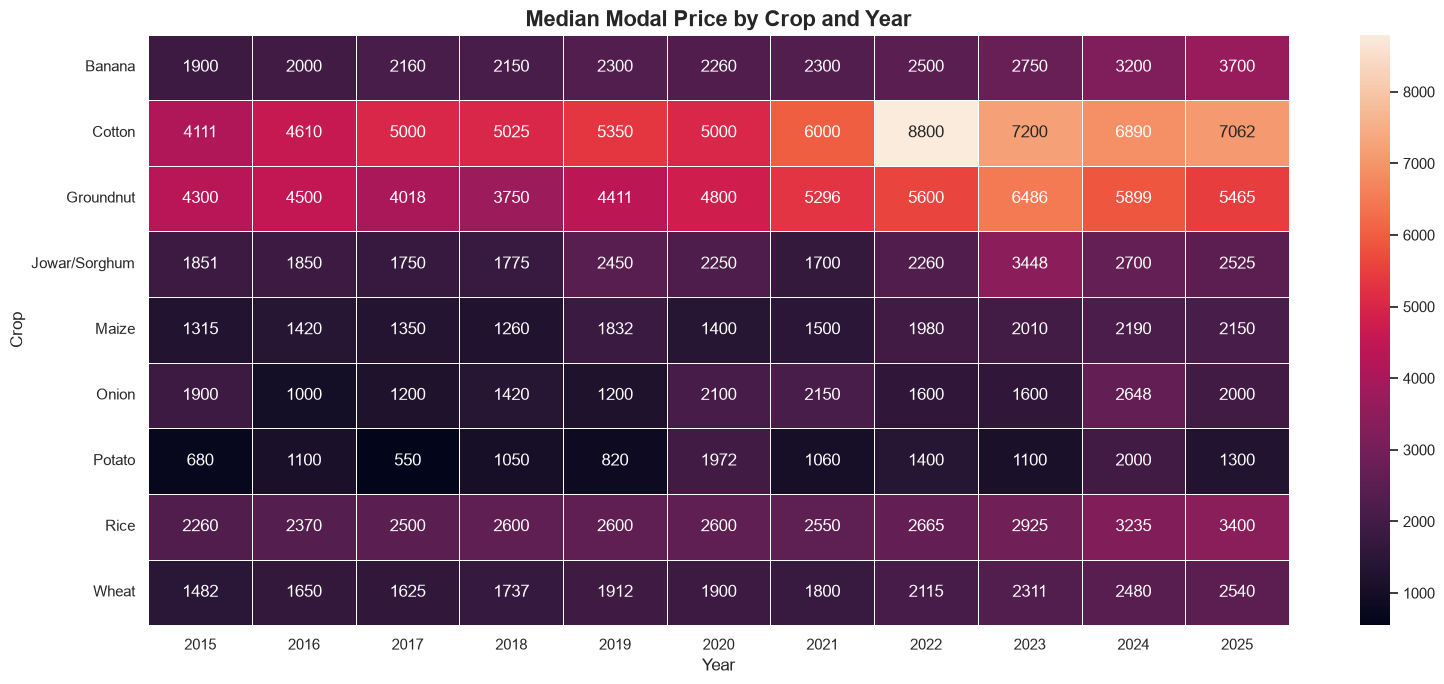

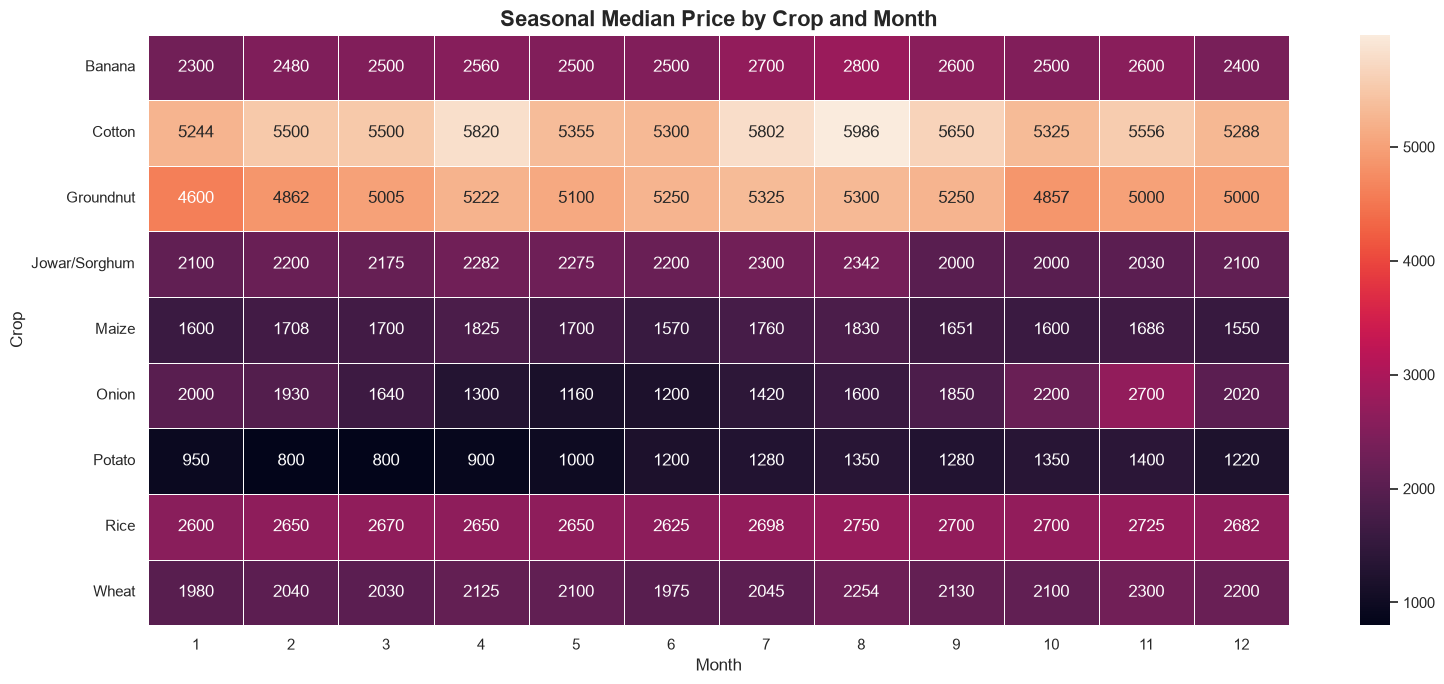


PRICE-RANGE ANOMALY ANALYSIS
Total anomaly observations: 611
Percentage of dataset: 0.1261%

Anomalies by crop:
Crop
Wheat        500
Maize         73
Onion         23
Groundnut      8
Potato         7

Anomalies by year:
Year
2024    611

Anomaly direction:
Anomaly_Direction
Above Maximum    342
Below Minimum    269

EXTREME PRICE CHECK
Threshold: ₹10,000
Observations >= threshold: 976

Extreme observations by crop:
Crop
Cotton       330
Banana       203
Groundnut    161
Onion        120
Lentil        90
Rice          37
Potato        32
Maize          3

Extreme observations by year:
Year
2015     29
2016     71
2017     29
2018      6
2019     16
2020     40
2021     30
2022    388
2023    158
2024     89
2025    120

MONTHLY COVERAGE CHECK
Total months: 132
Months with zero observations: 0
Lowest monthly observation count: 1,189
Highest monthly observation count: 5,713

EDA COMPLETE
Dataset observations analyzed: 484,504
Observations in complete-series EDA: 483,143
Crops analyzed:

C:\Users\acer\AppData\Local\Temp\ipykernel_3060\2841277912.py:1575: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  persistence.head(30).round(2)
C:\Users\acer\AppData\Local\Temp\ipykernel_3060\2841277912.py:1614: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  very_extreme_groups.round(2)


In [1]:
# ============================================================
# FOOD PRICE FORECASTING
# 03 - EXPLORATORY DATA ANALYSIS
# COMPLETE SINGLE-CELL VERSION
# ============================================================
# This cell combines the original EDA, extreme-price investigation,
# and extreme-price persistence analysis.
# Main comparative crop trends use only crops with complete 2015–2025
# monthly coverage. The full cleaned dataset remains in df.
# ============================================================

import sys
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# ============================================================
# 1. PROJECT PATHS
# ============================================================

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

DATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "agmarknet_cleaned_observations.csv"
)

OUTPUT_DIR = PROJECT_ROOT / "outputs" / "eda"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


# ============================================================
# 2. DISPLAY SETTINGS
# ============================================================

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)
pd.set_option("display.max_rows", 100)

sns.set_theme(style="whitegrid")


print("=" * 90)
print("FOOD PRICE FORECASTING — EXPLORATORY DATA ANALYSIS")
print("=" * 90)


# ============================================================
# 3. LOAD DATA
# ============================================================

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Cleaned dataset not found:\n{DATA_PATH}"
    )

df = pd.read_csv(DATA_PATH)

df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

print("\nDATASET LOADED")
print("-" * 90)
print(f"Path:       {DATA_PATH}")
print(f"Rows:       {len(df):,}")
print(f"Columns:    {len(df.columns)}")
print(f"Date range: {df['Date'].min().date()} → {df['Date'].max().date()}")


# ============================================================
# 4. BASIC VALIDATION
# ============================================================

expected_columns = [
    "Date",
    "Crop",
    "Commodity ID",
    "Commodity Group ID",
    "State",
    "State ID",
    "Market",
    "Market ID",
    "Variety",
    "Grade",
    "Minimum Price",
    "Maximum Price",
    "Modal Price",
    "Unit",
    "Price_Range_Anomaly",
]

missing_columns = [
    col for col in expected_columns
    if col not in df.columns
]

if missing_columns:
    raise ValueError(
        f"Missing expected columns: {missing_columns}"
    )

# The cleaned dataset produced by Notebook 02 contains the 14 analytical
# source fields plus Price_Range_Anomaly. Year and Month are recreated below
# from Date so the EDA remains reproducible from the cleaned observations.

if df["Date"].isna().any():
    raise ValueError(
        f"Invalid Date values found: {df['Date'].isna().sum():,}"
    )

if (df["Modal Price"] <= 0).any():
    raise ValueError(
        f"Non-positive Modal Price values found: {(df['Modal Price'] <= 0).sum():,}"
    )

print(f"Current cleaned schema: {len(df.columns)} columns")

if "Unit" in df.columns:
    units = sorted(df["Unit"].dropna().astype(str).unique())
    print(f"Price units present: {units}")


observation_key = [
    "Date",
    "Crop",
    "State ID",
    "Market ID",
    "Variety",
    "Grade",
]

print("\nBASIC VALIDATION")
print("-" * 90)
print(f"Missing expected columns: {missing_columns}")
print(f"Exact duplicate rows:      {df.duplicated().sum():,}")
print(
    f"Duplicate observation keys: "
    f"{df.duplicated(subset=observation_key).sum():,}"
)

print("\nMissing values:")
print(df.isna().sum())


# ============================================================
# 5. DATASET OVERVIEW
# ============================================================

print("\n" + "=" * 90)
print("DATASET OVERVIEW")
print("=" * 90)

print("\nUnique values:")
print(f"Dates:       {df['Date'].nunique():,}")
print(f"Crops:       {df['Crop'].nunique():,}")
print(f"States:      {df['State'].nunique():,}")
print(f"Markets:     {df['Market'].nunique():,}")
print(f"Varieties:   {df['Variety'].nunique():,}")
print(f"Grades:      {df['Grade'].nunique():,}")

print("\nCrops:")
print(sorted(df["Crop"].dropna().unique()))

print("\nPrice statistics:")
print(
    df[
        ["Minimum Price", "Maximum Price", "Modal Price"]
    ].describe().round(2)
)


# ============================================================
# 6. CROP-LEVEL SUMMARY
# ============================================================

crop_summary = (
    df.groupby("Crop")
    .agg(
        Observations=("Modal Price", "count"),
        Markets=("Market", "nunique"),
        States=("State", "nunique"),
        First_Date=("Date", "min"),
        Last_Date=("Date", "max"),
        Median_Price=("Modal Price", "median"),
        Mean_Price=("Modal Price", "mean"),
        Min_Price=("Modal Price", "min"),
        Max_Price=("Modal Price", "max"),
        Std_Price=("Modal Price", "std"),
    )
    .sort_values("Observations", ascending=False)
)

print("\n" + "=" * 90)
print("CROP-LEVEL SUMMARY")
print("=" * 90)

print(crop_summary.round(2))


# ============================================================
# 7. CREATE TIME FEATURES
# ============================================================

df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Month_Name"] = df["Date"].dt.month_name()
df["Year_Month"] = df["Date"].dt.to_period("M").astype(str)

# ============================================================
# 7A. COMPLETE CROP COVERAGE
# ============================================================

expected_months = pd.period_range(
    start="2015-01",
    end="2025-12",
    freq="M"
)

crop_month_presence = (
    df.assign(
        Year_Month_Period=df["Date"].dt.to_period("M")
    )
    .groupby("Crop")["Year_Month_Period"]
    .nunique()
)

coverage_rows = []

for crop in sorted(df["Crop"].dropna().unique()):
    observed = int(crop_month_presence.get(crop, 0))
    coverage_rows.append(
        {
            "Crop": crop,
            "Observed_2015_2025_Months": observed,
            "Expected_2015_2025_Months": len(expected_months),
            "Missing_2015_2025_Months": len(expected_months) - observed,
            "Complete_2015_2025": observed == len(expected_months),
        }
    )

crop_coverage = pd.DataFrame(coverage_rows)

COMPLETE_CROPS = crop_coverage.loc[
    crop_coverage["Complete_2015_2025"],
    "Crop"
].tolist()

INCOMPLETE_CROPS = crop_coverage.loc[
    ~crop_coverage["Complete_2015_2025"],
    "Crop"
].tolist()

print("\n" + "=" * 90)
print("CROP COVERAGE FOR EDA")
print("=" * 90)
print(crop_coverage.to_string(index=False))

print(
    f"\nComplete 2015–2025 crops used for comparative EDA: "
    f"{len(COMPLETE_CROPS)}"
)
print(COMPLETE_CROPS)

if INCOMPLETE_CROPS:
    print(
        "\nIncomplete crops retained in the dataset but excluded from "
        "complete-series comparative plots:"
    )
    print(INCOMPLETE_CROPS)

crop_coverage.to_csv(
    OUTPUT_DIR / "crop_coverage_2015_2025.csv",
    index=False
)

# Main comparative time-series/distribution analyses use only complete
# 2015–2025 crop series. The full cleaned dataset remains available in df.
eda_df = df[df["Crop"].isin(COMPLETE_CROPS)].copy()



# ============================================================
# 8. YEARLY SUMMARY
# ============================================================

yearly_summary = (
    df.groupby("Year")
    .agg(
        Observations=("Modal Price", "count"),
        Crops=("Crop", "nunique"),
        Markets=("Market", "nunique"),
        States=("State", "nunique"),
        Median_Price=("Modal Price", "median"),
        Mean_Price=("Modal Price", "mean"),
        Min_Price=("Modal Price", "min"),
        Max_Price=("Modal Price", "max"),
    )
)

print("\n" + "=" * 90)
print("YEARLY SUMMARY")
print("=" * 90)

print(yearly_summary.round(2))


# ============================================================
# 9. MONTHLY SUMMARY
# ============================================================

monthly_summary = (
    df.groupby("Year_Month")
    .agg(
        Observations=("Modal Price", "count"),
        Median_Price=("Modal Price", "median"),
        Mean_Price=("Modal Price", "mean"),
    )
)

print("\n" + "=" * 90)
print("MONTHLY SUMMARY — FIRST 20 MONTHS")
print("=" * 90)

print(monthly_summary.head(20).round(2))


# ============================================================
# 10. EXTREME PRICE ANALYSIS
# ============================================================

print("\n" + "=" * 90)
print("EXTREME PRICE ANALYSIS")
print("=" * 90)

print("\nHighest Modal Price observations:")

highest_prices = (
    df[
        [
            "Date",
            "Crop",
            "State",
            "Market",
            "Variety",
            "Grade",
            "Minimum Price",
            "Maximum Price",
            "Modal Price",
        ]
    ]
    .sort_values("Modal Price", ascending=False)
    .head(20)
)

print(highest_prices.to_string(index=False))


print("\nLowest Modal Price observations:")

lowest_prices = (
    df[
        [
            "Date",
            "Crop",
            "State",
            "Market",
            "Variety",
            "Grade",
            "Minimum Price",
            "Maximum Price",
            "Modal Price",
        ]
    ]
    .sort_values("Modal Price", ascending=True)
    .head(20)
)

print(lowest_prices.to_string(index=False))


# ============================================================
# 11. TOP 1% PRICE THRESHOLD
# ============================================================

price_99 = df["Modal Price"].quantile(0.99)

top_1_percent = df[
    df["Modal Price"] >= price_99
].copy()

print("\n" + "=" * 90)
print("TOP 1% PRICE ANALYSIS")
print("=" * 90)

print(f"99th percentile price: ₹{price_99:,.2f}")
print(f"Observations in top 1%: {len(top_1_percent):,}")

print("\nTop 1% observations by crop:")
print(
    top_1_percent["Crop"]
    .value_counts()
    .to_string()
)


# ============================================================
# 12. CROP PRICE DISTRIBUTION
# ============================================================

plt.figure(figsize=(14, 7))

sns.boxplot(
    data=df,
    x="Crop",
    y="Modal Price"
)

plt.title(
    "Food Commodity Price Distribution by Crop",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Crop")
plt.ylabel("Modal Price (₹ per Quintal)")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "01_crop_price_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 13. CROP MEDIAN PRICE COMPARISON
# ============================================================

crop_median = (
    eda_df.groupby("Crop")["Modal Price"]
    .median()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12, 7))

sns.barplot(
    x=crop_median.values,
    y=crop_median.index
)

plt.title(
    "Median Modal Price by Crop",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Median Modal Price (₹ per Quintal)")
plt.ylabel("Crop")

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "02_median_price_by_crop.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 14. OVERALL MONTHLY PRICE TREND
# ============================================================

overall_monthly = (
    df.groupby("Year_Month")["Modal Price"]
    .median()
    .reset_index()
)

overall_monthly["Date"] = pd.to_datetime(
    overall_monthly["Year_Month"]
)

plt.figure(figsize=(16, 7))

plt.plot(
    overall_monthly["Date"],
    overall_monthly["Modal Price"],
    linewidth=2
)

plt.title(
    "Overall Monthly Median Food Price Trend",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Date")
plt.ylabel("Median Modal Price (₹ per Quintal)")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "03_overall_monthly_price_trend.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 15. CROP-WISE MONTHLY PRICE TRENDS
# ============================================================

crop_monthly = (
    eda_df.groupby(["Year_Month", "Crop"])["Modal Price"]
    .median()
    .reset_index()
)

crop_monthly["Date"] = pd.to_datetime(
    crop_monthly["Year_Month"]
)

plt.figure(figsize=(18, 9))

for crop in sorted(crop_monthly["Crop"].unique()):

    crop_data = crop_monthly[
        crop_monthly["Crop"] == crop
    ]

    plt.plot(
        crop_data["Date"],
        crop_data["Modal Price"],
        linewidth=1.7,
        label=crop
    )

plt.title(
    "Monthly Median Price Trends by Crop",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Date")
plt.ylabel("Median Modal Price (₹ per Quintal)")

plt.legend(
    title="Crop",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "04_crop_monthly_price_trends.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 16. YEARLY MEDIAN PRICE BY CROP
# ============================================================

year_crop = (
    eda_df.groupby(["Year", "Crop"])["Modal Price"]
    .median()
    .reset_index()
)

plt.figure(figsize=(16, 8))

sns.lineplot(
    data=year_crop,
    x="Year",
    y="Modal Price",
    hue="Crop",
    marker="o"
)

plt.title(
    "Yearly Median Price Trends by Crop",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Year")
plt.ylabel("Median Modal Price (₹ per Quintal)")

plt.legend(
    title="Crop",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "05_yearly_crop_price_trends.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 17. SEASONAL MONTHLY PATTERNS
# ============================================================

seasonal_monthly = (
    eda_df.groupby(["Month", "Month_Name", "Crop"])["Modal Price"]
    .median()
    .reset_index()
)

month_order = [
    "January",
    "February",
    "March",
    "April",
    "May",
    "June",
    "July",
    "August",
    "September",
    "October",
    "November",
    "December",
]

seasonal_monthly["Month_Name"] = pd.Categorical(
    seasonal_monthly["Month_Name"],
    categories=month_order,
    ordered=True
)

seasonal_overall = (
    eda_df.groupby(["Month", "Month_Name"])["Modal Price"]
    .median()
    .reset_index()
)

seasonal_overall["Month_Name"] = pd.Categorical(
    seasonal_overall["Month_Name"],
    categories=month_order,
    ordered=True
)

seasonal_overall = seasonal_overall.sort_values("Month")


plt.figure(figsize=(14, 7))

sns.lineplot(
    data=seasonal_overall,
    x="Month_Name",
    y="Modal Price",
    marker="o",
    linewidth=2.5
)

plt.title(
    "Seasonal Monthly Price Pattern",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Month")
plt.ylabel("Median Modal Price (₹ per Quintal)")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "06_seasonal_monthly_pattern.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 18. SEASONAL PATTERN BY CROP
# ============================================================

plt.figure(figsize=(17, 9))

sns.lineplot(
    data=seasonal_monthly,
    x="Month_Name",
    y="Modal Price",
    hue="Crop",
    marker="o"
)

plt.title(
    "Seasonal Price Patterns by Crop",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Month")
plt.ylabel("Median Modal Price (₹ per Quintal)")

plt.xticks(rotation=45)

plt.legend(
    title="Crop",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "07_seasonal_patterns_by_crop.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 19. PRICE VOLATILITY BY CROP
# ============================================================

volatility_summary = (
    eda_df.groupby("Crop")["Modal Price"]
    .agg(
        Mean="mean",
        Std="std",
        Median="median",
        Min="min",
        Max="max"
    )
)

volatility_summary["Coefficient_of_Variation"] = (
    volatility_summary["Std"]
    / volatility_summary["Mean"]
)

volatility_summary = volatility_summary.sort_values(
    "Coefficient_of_Variation",
    ascending=False
)

print("\n" + "=" * 90)
print("PRICE VOLATILITY BY CROP")
print("=" * 90)

print(
    volatility_summary.round(3)
)


plt.figure(figsize=(12, 7))

sns.barplot(
    x=volatility_summary["Coefficient_of_Variation"],
    y=volatility_summary.index
)

plt.title(
    "Price Volatility by Crop — Coefficient of Variation",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Coefficient of Variation")
plt.ylabel("Crop")

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "08_price_volatility_by_crop.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 20. PRICE DISTRIBUTION
# ============================================================

plt.figure(figsize=(13, 7))

sns.histplot(
    df["Modal Price"],
    bins=100,
    kde=True
)

plt.title(
    "Distribution of Modal Prices",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Modal Price (₹ per Quintal)")
plt.ylabel("Number of Observations")

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "09_modal_price_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 21. LOG-TRANSFORMED PRICE DISTRIBUTION
# ============================================================

df["Log_Modal_Price"] = np.log1p(
    df["Modal Price"]
)

plt.figure(figsize=(13, 7))

sns.histplot(
    df["Log_Modal_Price"],
    bins=100,
    kde=True
)

plt.title(
    "Log-Transformed Modal Price Distribution",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("log(1 + Modal Price)")
plt.ylabel("Number of Observations")

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "10_log_modal_price_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 22. STATE-LEVEL ANALYSIS
# ============================================================

state_summary = (
    df.groupby("State")
    .agg(
        Observations=("Modal Price", "count"),
        Markets=("Market", "nunique"),
        Crops=("Crop", "nunique"),
        Median_Price=("Modal Price", "median"),
        Mean_Price=("Modal Price", "mean"),
    )
    .sort_values("Observations", ascending=False)
)

print("\n" + "=" * 90)
print("TOP STATES BY OBSERVATION COUNT")
print("=" * 90)

print(state_summary.head(20).round(2))


# ============================================================
# 23. TOP MARKETS BY OBSERVATION COUNT
# ============================================================

market_summary = (
    df.groupby(["State", "Market"])
    .agg(
        Observations=("Modal Price", "count"),
        Crops=("Crop", "nunique"),
        Median_Price=("Modal Price", "median"),
        Mean_Price=("Modal Price", "mean"),
    )
    .sort_values("Observations", ascending=False)
)

print("\n" + "=" * 90)
print("TOP 20 MARKETS BY OBSERVATION COUNT")
print("=" * 90)

print(
    market_summary.head(20).round(2)
)


# ============================================================
# 24. CROP × YEAR HEATMAP
# ============================================================

crop_year_median = (
    eda_df.groupby(["Crop", "Year"])["Modal Price"]
    .median()
    .unstack()
)

plt.figure(figsize=(16, 7))

sns.heatmap(
    crop_year_median,
    annot=True,
    fmt=".0f",
    linewidths=0.5
)

plt.title(
    "Median Modal Price by Crop and Year",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Year")
plt.ylabel("Crop")

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "11_crop_year_price_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 25. CROP × MONTH SEASONAL HEATMAP
# ============================================================

crop_month_median = (
    eda_df.groupby(["Crop", "Month"])["Modal Price"]
    .median()
    .unstack()
)

crop_month_median = crop_month_median.reindex(
    columns=range(1, 13)
)

plt.figure(figsize=(16, 7))

sns.heatmap(
    crop_month_median,
    annot=True,
    fmt=".0f",
    linewidths=0.5
)

plt.title(
    "Seasonal Median Price by Crop and Month",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Month")
plt.ylabel("Crop")

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "12_crop_month_seasonal_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 26. PRICE-RANGE ANOMALY ANALYSIS
# ============================================================

anomaly_df = df[
    df["Price_Range_Anomaly"] == True
].copy()

print("\n" + "=" * 90)
print("PRICE-RANGE ANOMALY ANALYSIS")
print("=" * 90)

print(f"Total anomaly observations: {len(anomaly_df):,}")
print(
    f"Percentage of dataset: "
    f"{len(anomaly_df) / len(df) * 100:.4f}%"
)

if len(anomaly_df) > 0:

    print("\nAnomalies by crop:")
    print(
        anomaly_df["Crop"]
        .value_counts()
        .to_string()
    )

    print("\nAnomalies by year:")
    print(
        anomaly_df["Year"]
        .value_counts()
        .sort_index()
        .to_string()
    )

    print("\nAnomaly direction:")

    anomaly_df["Anomaly_Direction"] = np.select(
        [
            anomaly_df["Modal Price"] < anomaly_df["Minimum Price"],
            anomaly_df["Modal Price"] > anomaly_df["Maximum Price"],
        ],
        [
            "Below Minimum",
            "Above Maximum",
        ],
        default="Other"
    )

    print(
        anomaly_df["Anomaly_Direction"]
        .value_counts()
        .to_string()
    )


# ============================================================
# 27. EXTREME PRICE CHECK
# ============================================================

extreme_threshold = 10000

extreme_prices = df[
    df["Modal Price"] >= extreme_threshold
].copy()

print("\n" + "=" * 90)
print("EXTREME PRICE CHECK")
print("=" * 90)

print(
    f"Threshold: ₹{extreme_threshold:,}"
)

print(
    f"Observations >= threshold: "
    f"{len(extreme_prices):,}"
)

if len(extreme_prices) > 0:

    print("\nExtreme observations by crop:")
    print(
        extreme_prices["Crop"]
        .value_counts()
        .to_string()
    )

    print("\nExtreme observations by year:")
    print(
        extreme_prices["Year"]
        .value_counts()
        .sort_index()
        .to_string()
    )


# ============================================================
# 28. MONTHLY OBSERVATION COVERAGE
# ============================================================

monthly_coverage = (
    df.groupby("Year_Month")
    .agg(
        Observations=("Modal Price", "count"),
        Crops=("Crop", "nunique"),
        Markets=("Market", "nunique"),
        States=("State", "nunique"),
    )
)

print("\n" + "=" * 90)
print("MONTHLY COVERAGE CHECK")
print("=" * 90)

print(
    f"Total months: {len(monthly_coverage):,}"
)

print(
    f"Months with zero observations: "
    f"{(monthly_coverage['Observations'] == 0).sum():,}"
)

print(
    f"Lowest monthly observation count: "
    f"{monthly_coverage['Observations'].min():,}"
)

print(
    f"Highest monthly observation count: "
    f"{monthly_coverage['Observations'].max():,}"
)


# ============================================================
# 29. SAVE SUMMARY TABLES
# ============================================================

crop_summary.to_csv(
    OUTPUT_DIR / "crop_summary.csv"
)

yearly_summary.to_csv(
    OUTPUT_DIR / "yearly_summary.csv"
)

monthly_summary.to_csv(
    OUTPUT_DIR / "monthly_summary.csv"
)

volatility_summary.to_csv(
    OUTPUT_DIR / "price_volatility_summary.csv"
)

state_summary.to_csv(
    OUTPUT_DIR / "state_summary.csv"
)

market_summary.to_csv(
    OUTPUT_DIR / "market_summary.csv"
)


# ============================================================
# 30. SAVE EXTREME PRICE OBSERVATIONS
# ============================================================

highest_prices.to_csv(
    OUTPUT_DIR / "highest_price_observations.csv",
    index=False
)

lowest_prices.to_csv(
    OUTPUT_DIR / "lowest_price_observations.csv",
    index=False
)

if len(anomaly_df) > 0:
    anomaly_df.to_csv(
        OUTPUT_DIR / "price_range_anomalies.csv",
        index=False
    )

if len(extreme_prices) > 0:
    extreme_prices.to_csv(
        OUTPUT_DIR / "extreme_price_observations.csv",
        index=False
    )


# ============================================================
# 31. FINAL EDA SUMMARY
# ============================================================

print("\n" + "=" * 90)
print("EDA COMPLETE")
print("=" * 90)

print(f"Dataset observations analyzed: {len(df):,}")
print(f"Observations in complete-series EDA: {len(eda_df):,}")
print(f"Crops analyzed:               {df['Crop'].nunique()}")
print(f"Complete-series crops:        {len(COMPLETE_CROPS)}")
print(f"States analyzed:              {df['State'].nunique()}")
print(f"Markets analyzed:             {df['Market'].nunique()}")
print(
    f"Date range:                   "
    f"{df['Date'].min().date()} → {df['Date'].max().date()}"
)
print(
    f"Price-range anomalies:        "
    f"{df['Price_Range_Anomaly'].sum():,}"
)
print(
    f"Maximum Modal Price:          "
    f"₹{df['Modal Price'].max():,.2f}"
)

print(f"\nEDA outputs saved to:")
print(OUTPUT_DIR)

print("\nGenerated visualizations:")
for file in sorted(OUTPUT_DIR.glob("*.png")):
    print(f"  ✓ {file.name}")

print("\nGenerated summary files:")
for file in sorted(OUTPUT_DIR.glob("*.csv")):
    print(f"  ✓ {file.name}")

print("\n" + "=" * 90)
print("NEXT STAGE: FEATURE ENGINEERING")
print("=" * 90)


# ============================================================
# EXTREME PRICE INVESTIGATION
# ============================================================

print("=" * 90)
print("EXTREME MODAL PRICE INVESTIGATION")
print("=" * 90)


# ------------------------------------------------------------
# 1. PRICE THRESHOLDS
# ------------------------------------------------------------

thresholds = [5000, 7500, 10000, 20000, 50000, 100000]

print("\nObservations above selected price thresholds:")
print("-" * 90)

for threshold in thresholds:
    count = (df["Modal Price"] >= threshold).sum()
    percentage = count / len(df) * 100

    print(
        f"₹{threshold:>7,} and above: "
        f"{count:>7,} observations "
        f"({percentage:.4f}%)"
    )


# ------------------------------------------------------------
# 2. EXTREME OBSERVATIONS BY CROP
# ------------------------------------------------------------

extreme_crop = (
    df[df["Modal Price"] >= 10000]
    .groupby("Crop")
    .agg(
        Observations=("Modal Price", "count"),
        Median_Price=("Modal Price", "median"),
        Mean_Price=("Modal Price", "mean"),
        Maximum_Price=("Modal Price", "max")
    )
    .sort_values("Observations", ascending=False)
)

print("\n" + "=" * 90)
print("OBSERVATIONS ≥ ₹10,000 BY CROP")
print("=" * 90)

print(extreme_crop.round(2))


# ------------------------------------------------------------
# 3. EXTREME OBSERVATIONS BY STATE
# ------------------------------------------------------------

extreme_state = (
    df[df["Modal Price"] >= 10000]
    .groupby("State")
    .agg(
        Observations=("Modal Price", "count"),
        Crops=("Crop", "nunique"),
        Markets=("Market", "nunique"),
        Maximum_Price=("Modal Price", "max")
    )
    .sort_values("Observations", ascending=False)
)

print("\n" + "=" * 90)
print("OBSERVATIONS ≥ ₹10,000 BY STATE")
print("=" * 90)

print(extreme_state.head(20).round(2))


# ------------------------------------------------------------
# 4. EXTREME OBSERVATIONS BY MARKET
# ------------------------------------------------------------

extreme_market = (
    df[df["Modal Price"] >= 10000]
    .groupby(["State", "Market", "Crop"])
    .agg(
        Observations=("Modal Price", "count"),
        Maximum_Price=("Modal Price", "max"),
        Median_Price=("Modal Price", "median")
    )
    .sort_values(
        ["Observations", "Maximum_Price"],
        ascending=False
    )
)

print("\n" + "=" * 90)
print("TOP MARKET/CROP COMBINATIONS WITH PRICES ≥ ₹10,000")
print("=" * 90)

print(
    extreme_market
    .head(30)
    .round(2)
)


# ------------------------------------------------------------
# 5. EXTREME OBSERVATIONS BY YEAR
# ------------------------------------------------------------

extreme_year = (
    df[df["Modal Price"] >= 10000]
    .groupby("Year")
    .agg(
        Observations=("Modal Price", "count"),
        Maximum_Price=("Modal Price", "max"),
        Median_Price=("Modal Price", "median")
    )
    .sort_index()
)

print("\n" + "=" * 90)
print("OBSERVATIONS ≥ ₹10,000 BY YEAR")
print("=" * 90)

print(extreme_year.round(2))


# ------------------------------------------------------------
# 6. INVESTIGATE THE ₹100,000+ OBSERVATIONS
# ------------------------------------------------------------

very_extreme = (
    df[df["Modal Price"] >= 100000]
    [
        [
            "Date",
            "Crop",
            "State",
            "Market",
            "Variety",
            "Grade",
            "Minimum Price",
            "Maximum Price",
            "Modal Price",
            "Unit"
        ]
    ]
    .sort_values("Modal Price", ascending=False)
)

print("\n" + "=" * 90)
print("VERY EXTREME OBSERVATIONS — ₹100,000+")
print("=" * 90)

print(
    f"Number of observations: {len(very_extreme):,}"
)

if len(very_extreme) > 0:
    print(
        very_extreme.to_string(index=False)
    )
else:
    print("No observations found.")


# ------------------------------------------------------------
# 7. CHECK WHETHER EXTREME VALUES ARE CONSISTENT
#    WITH THEIR MINIMUM/MAXIMUM PRICE RANGE
# ------------------------------------------------------------

if len(very_extreme) > 0:

    print("\n" + "=" * 90)
    print("EXTREME VALUE RANGE CONSISTENCY")
    print("=" * 90)

    extreme_range_check = very_extreme.copy()

    extreme_range_check["Within_Range"] = (
        extreme_range_check["Minimum Price"].isna()
        | extreme_range_check["Maximum Price"].isna()
        | (
            (extreme_range_check["Modal Price"] >= extreme_range_check["Minimum Price"])
            & (extreme_range_check["Modal Price"] <= extreme_range_check["Maximum Price"])
        )
    )

    print(
        extreme_range_check[
            [
                "Crop",
                "State",
                "Market",
                "Minimum Price",
                "Maximum Price",
                "Modal Price",
                "Within_Range"
            ]
        ].to_string(index=False)
    )


# ------------------------------------------------------------
# 8. SAVE EXTREME INVESTIGATION
# ------------------------------------------------------------

extreme_investigation_path = (
    OUTPUT_DIR / "extreme_price_investigation.csv"
)

df[
    df["Modal Price"] >= 10000
].sort_values(
    "Modal Price",
    ascending=False
).to_csv(
    extreme_investigation_path,
    index=False
)


print("\n" + "=" * 90)
print("EXTREME PRICE INVESTIGATION COMPLETE")
print("=" * 90)

print(
    f"Saved: {extreme_investigation_path}"
)


# ============================================================
# EXTREME PRICE PERSISTENCE ANALYSIS
# ============================================================

print("=" * 90)
print("EXTREME PRICE PERSISTENCE ANALYSIS")
print("=" * 90)


# ------------------------------------------------------------
# 1. CREATE PRICE BANDS
# ------------------------------------------------------------

df["Price_Band"] = pd.cut(
    df["Modal Price"],
    bins=[
        0,
        2000,
        5000,
        7500,
        10000,
        20000,
        50000,
        100000,
        np.inf
    ],
    labels=[
        "< ₹2,000",
        "₹2,000–₹5,000",
        "₹5,000–₹7,500",
        "₹7,500–₹10,000",
        "₹10,000–₹20,000",
        "₹20,000–₹50,000",
        "₹50,000–₹100,000",
        "≥ ₹100,000"
    ],
    include_lowest=True
)


print("\nPRICE BAND DISTRIBUTION")
print("-" * 90)

price_band_summary = (
    df["Price_Band"]
    .value_counts()
    .sort_index()
)

price_band_percentage = (
    price_band_summary
    / len(df)
    * 100
)

price_band_table = pd.DataFrame({
    "Observations": price_band_summary,
    "Percentage": price_band_percentage
})

print(price_band_table.round(4))


# ------------------------------------------------------------
# 2. EXTREME OBSERVATIONS BY CROP + MARKET + VARIETY
# ------------------------------------------------------------

extreme = df[
    df["Modal Price"] >= 10000
].copy()

persistence = (
    extreme
    .groupby(
        [
            "Crop",
            "State",
            "Market",
            "Variety",
            "Grade"
        ]
    )
    .agg(
        Extreme_Observations=("Modal Price", "count"),
        Maximum_Price=("Modal Price", "max"),
        Median_Price=("Modal Price", "median"),
        First_Date=("Date", "min"),
        Last_Date=("Date", "max")
    )
    .sort_values(
        [
            "Extreme_Observations",
            "Maximum_Price"
        ],
        ascending=False
    )
)

print("\n" + "=" * 90)
print("MOST PERSISTENT EXTREME PRICE GROUPS")
print("=" * 90)

print(
    persistence.head(30).round(2)
)


# ------------------------------------------------------------
# 3. CHECK THE VERY EXTREME GROUPS
# ------------------------------------------------------------

very_extreme_groups = (
    df[
        df["Modal Price"] >= 50000
    ]
    .groupby(
        [
            "Crop",
            "State",
            "Market",
            "Variety",
            "Grade"
        ]
    )
    .agg(
        Observations=("Modal Price", "count"),
        Maximum_Price=("Modal Price", "max"),
        Median_Price=("Modal Price", "median"),
        First_Date=("Date", "min"),
        Last_Date=("Date", "max")
    )
    .sort_values(
        "Maximum_Price",
        ascending=False
    )
)

print("\n" + "=" * 90)
print("GROUPS WITH PRICES ≥ ₹50,000")
print("=" * 90)

print(
    very_extreme_groups.round(2)
)


# ------------------------------------------------------------
# 4. COUNT EXTREME RECORDS THAT ARE ISOLATED
# ------------------------------------------------------------

group_sizes = (
    extreme
    .groupby(
        [
            "Crop",
            "State",
            "Market",
            "Variety",
            "Grade"
        ]
    )
    .size()
)

isolated_count = (
    group_sizes[group_sizes == 1]
    .sum()
)

persistent_count = (
    group_sizes[group_sizes > 1]
    .sum()
)

print("\n" + "=" * 90)
print("ISOLATED VS PERSISTENT EXTREME OBSERVATIONS")
print("=" * 90)

print(
    f"Extreme observations (≥ ₹10,000): {len(extreme):,}"
)

print(
    f"Isolated extreme observations:      {isolated_count:,}"
)

print(
    f"Persistent extreme observations:    {persistent_count:,}"
)

print(
    f"Unique extreme groups:              {len(group_sizes):,}"
)

print(
    f"Groups occurring more than once:   "
    f"{(group_sizes > 1).sum():,}"
)


# ------------------------------------------------------------
# 5. EXTREME OBSERVATIONS BY CROP AND PRICE BAND
# ------------------------------------------------------------

extreme_band_crop = pd.crosstab(
    df["Crop"],
    df["Price_Band"]
)

print("\n" + "=" * 90)
print("PRICE BANDS BY CROP")
print("=" * 90)

print(
    extreme_band_crop.to_string()
)


# ------------------------------------------------------------
# 6. SAVE RESULTS
# ------------------------------------------------------------

price_band_table.to_csv(
    OUTPUT_DIR / "price_band_summary.csv"
)

persistence.to_csv(
    OUTPUT_DIR / "extreme_price_persistence.csv"
)

very_extreme_groups.to_csv(
    OUTPUT_DIR / "very_extreme_groups.csv"
)

extreme_band_crop.to_csv(
    OUTPUT_DIR / "crop_price_band_distribution.csv"
)


# ------------------------------------------------------------
# 7. COMPLETION
# ------------------------------------------------------------

print("\n" + "=" * 90)
print("PERSISTENCE ANALYSIS COMPLETE")
print("=" * 90)

print(
    "Saved:"
)

print("  ✓ price_band_summary.csv")
print("  ✓ extreme_price_persistence.csv")
print("  ✓ very_extreme_groups.csv")
print("  ✓ crop_price_band_distribution.csv")


FOOD PRICE FORECASTING — EXPLORATORY DATA ANALYSIS

DATASET LOADED
------------------------------------------------------------------------------------------
Path:       d:\OneDrive\Documents\Desktop\Resume Projects\Food Price Forecasting\data\processed\agmarknet_cleaned_observations.csv
Rows:       450,008
Columns:    15
Date range: 2015-01-01 → 2025-12-08

BASIC VALIDATION
------------------------------------------------------------------------------------------
Missing expected columns: []
Exact duplicate rows:      0
Duplicate observation keys: 0

Missing values:
Date                      0
Crop                      0
Commodity ID              0
Commodity Group ID        0
State                     0
State ID                  0
Market                    0
Market ID                 0
Variety                   0
Grade                     0
Minimum Price          7234
Maximum Price          7158
Modal Price               0
Unit                      0
Price_Range_Anomaly       0
dtype:

C:\Users\acer\AppData\Local\Temp\ipykernel_9584\2389840495.py:178: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  print(crop_summary.round(2))



YEARLY SUMMARY
      Observations  Crops  Markets  States  Median_Price  Mean_Price  Min_Price  Max_Price
Year                                                                                      
2015         38442      9     2061      31        1750.0     2119.40       13.0    40000.0
2016         40336      9     2060      31        1650.0     2085.49        1.0   210000.0
2017         42254      9     2139      31        1635.0     2095.02       10.0    12627.0
2018         42982      9     2179      30        1735.0     2105.48        2.0    16100.0
2019         45479      9     2108      30        1940.0     2240.98      100.0    12800.0
2020         30442      9     1778      25        2075.0     2483.21      100.0    40000.0
2021         35927      8     1715      27        2000.0     2456.21      160.5    15609.0
2022         43182      8     1871      28        2200.0     2822.83      145.0   500000.0
2023         37696      8     1931      29        2465.0     3101.51      

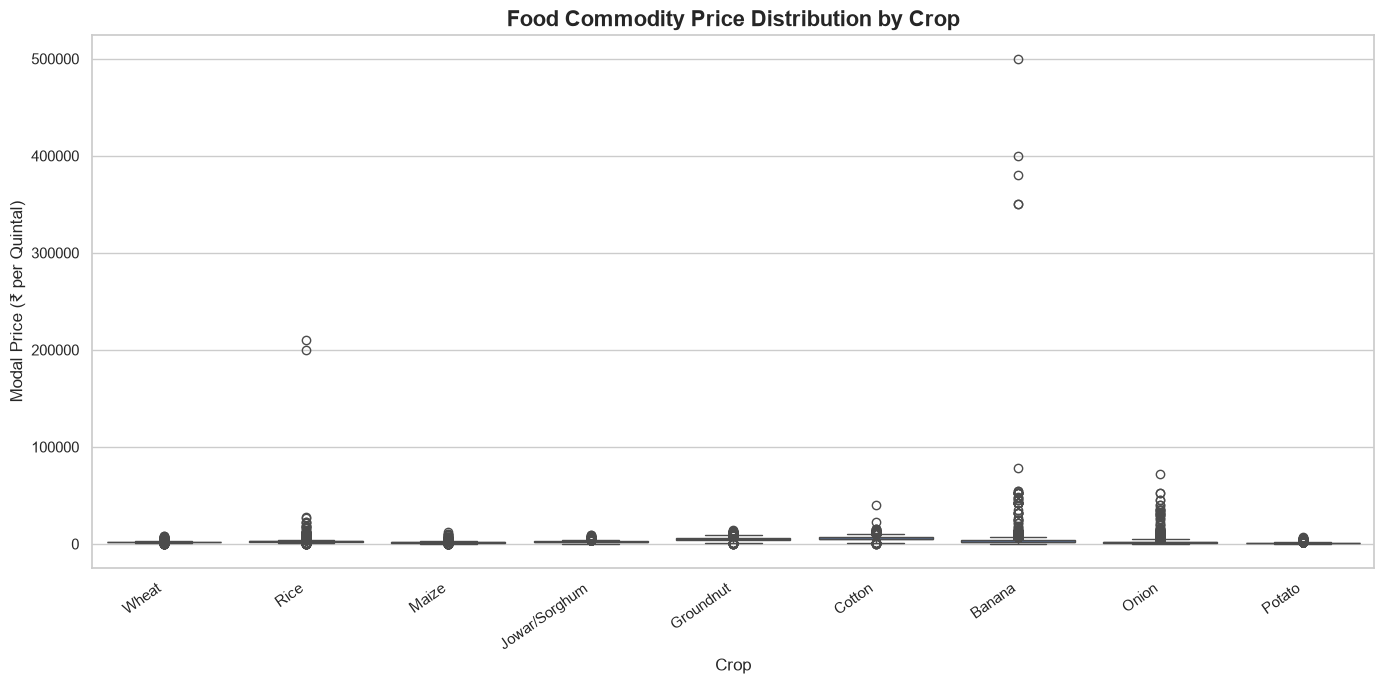

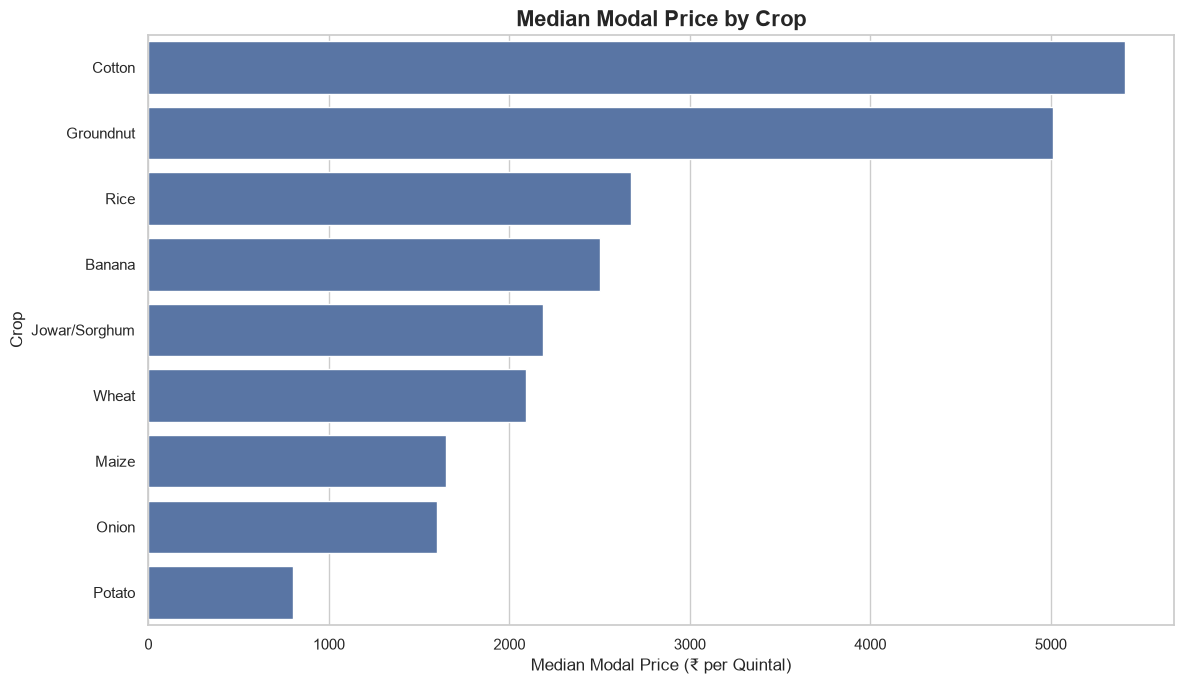

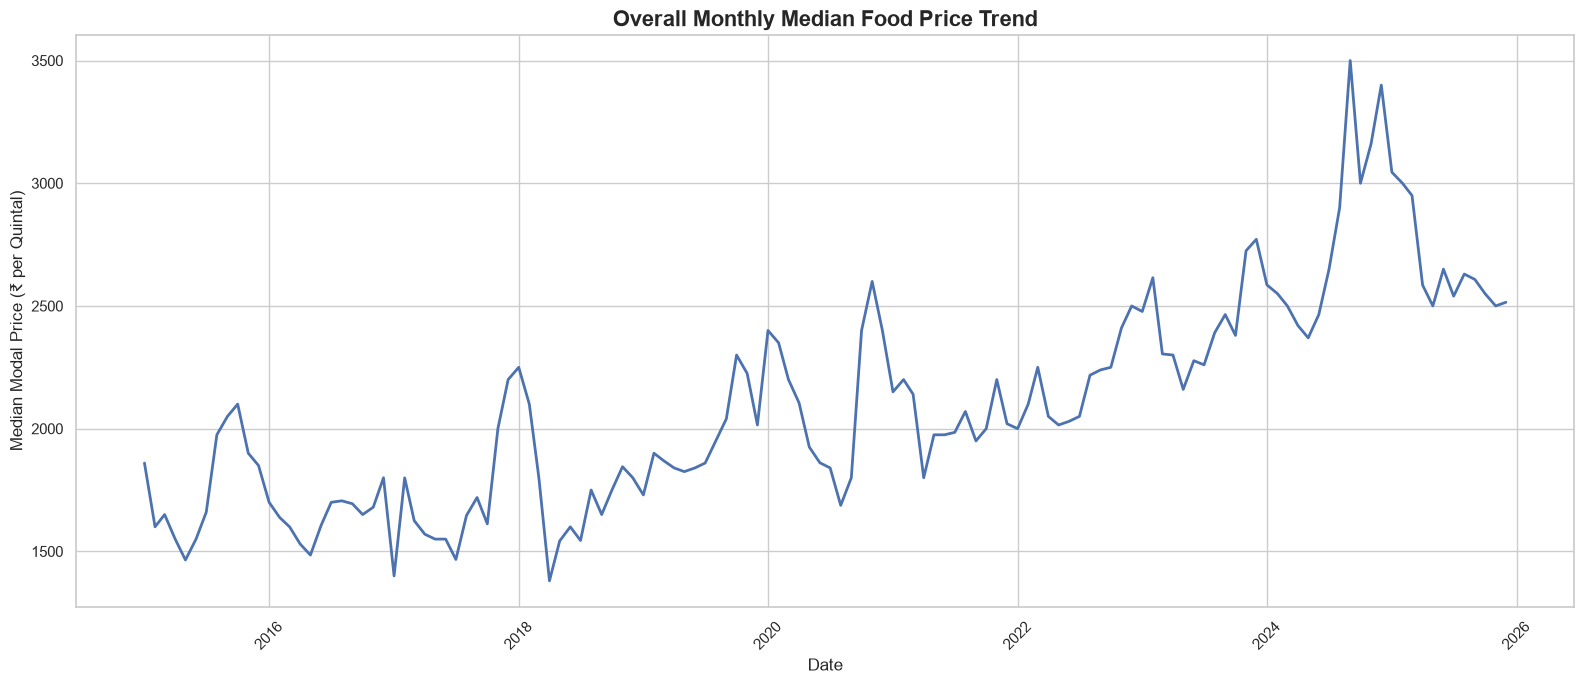

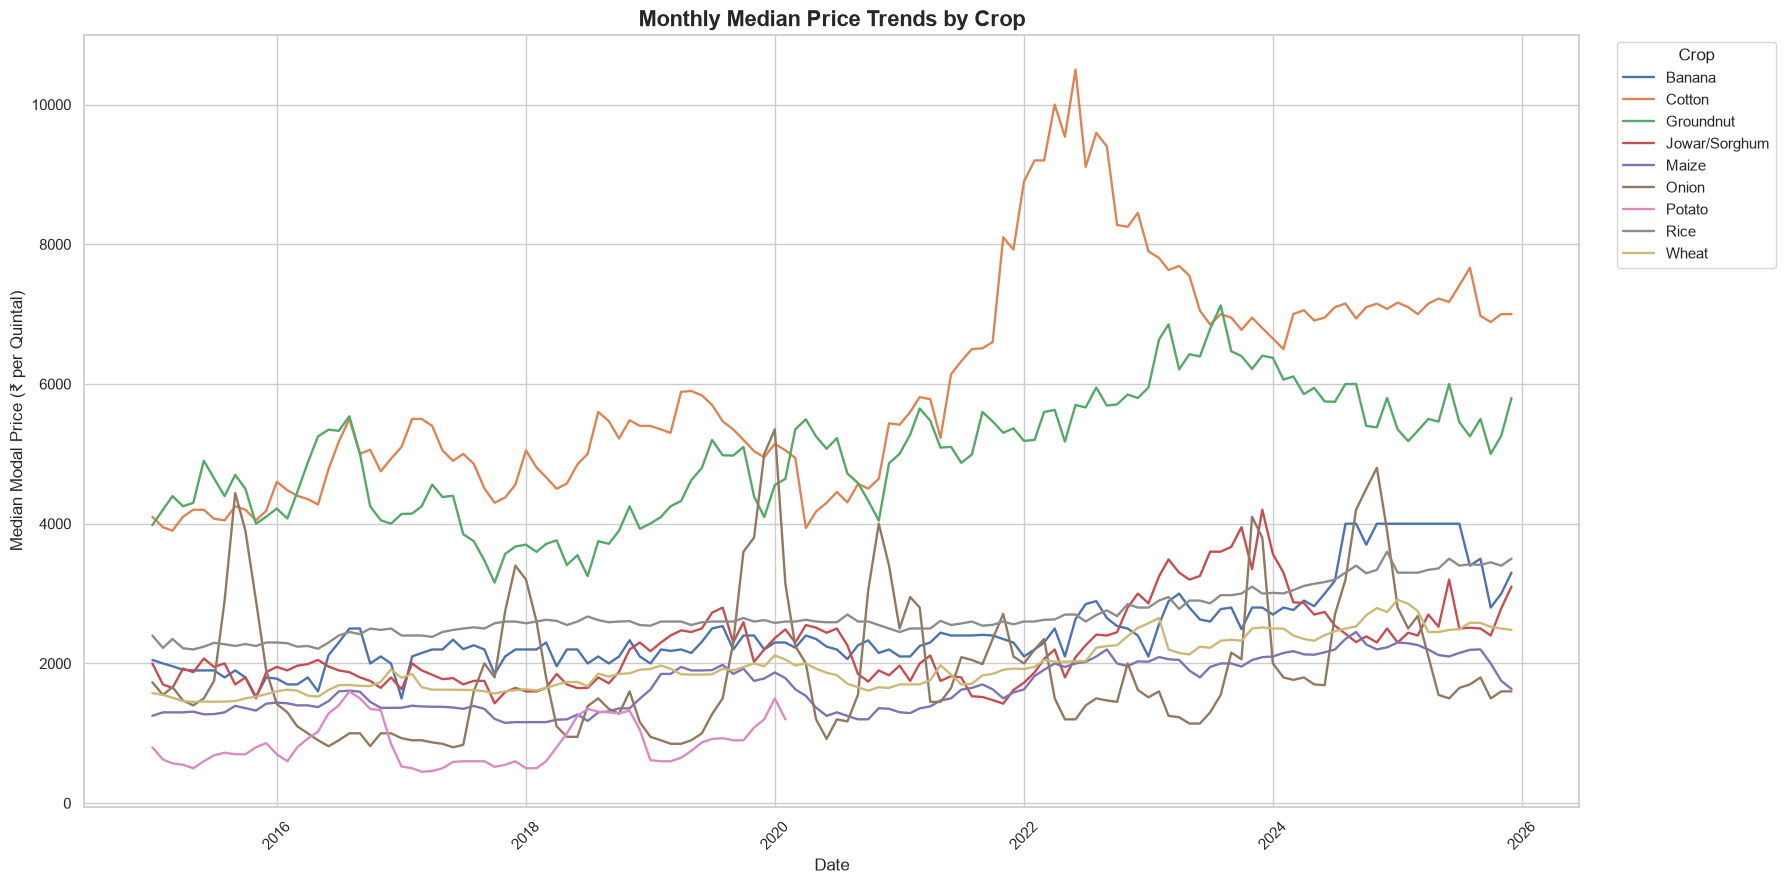

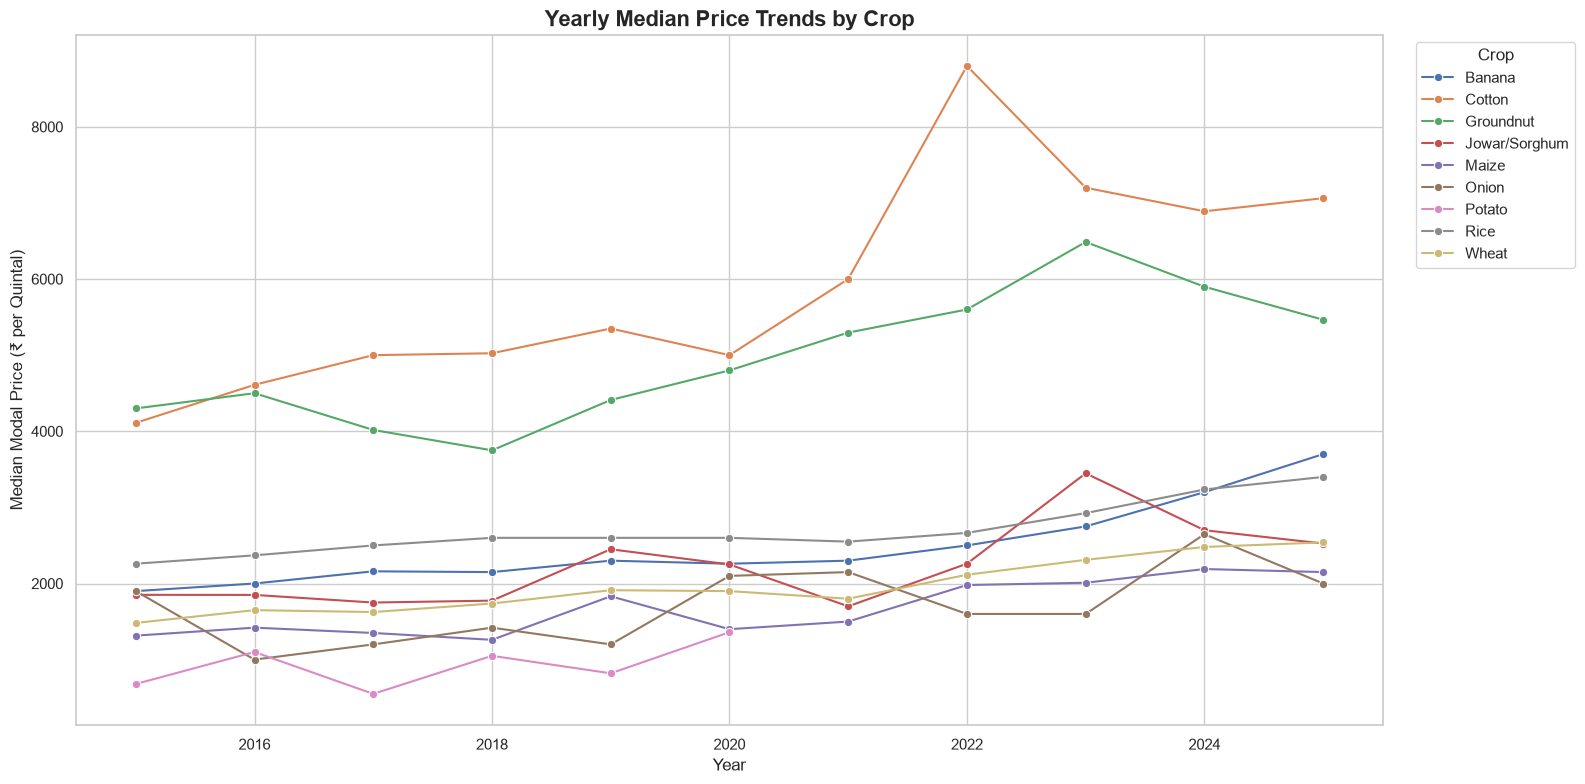

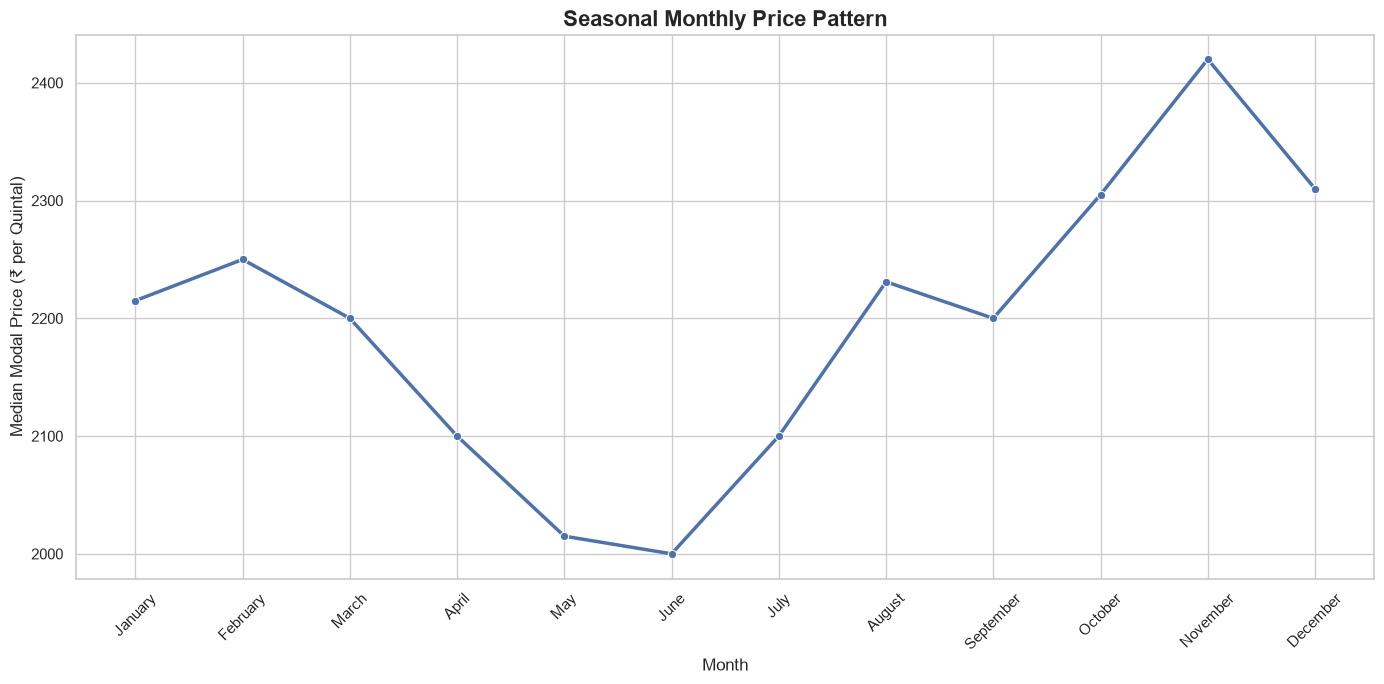

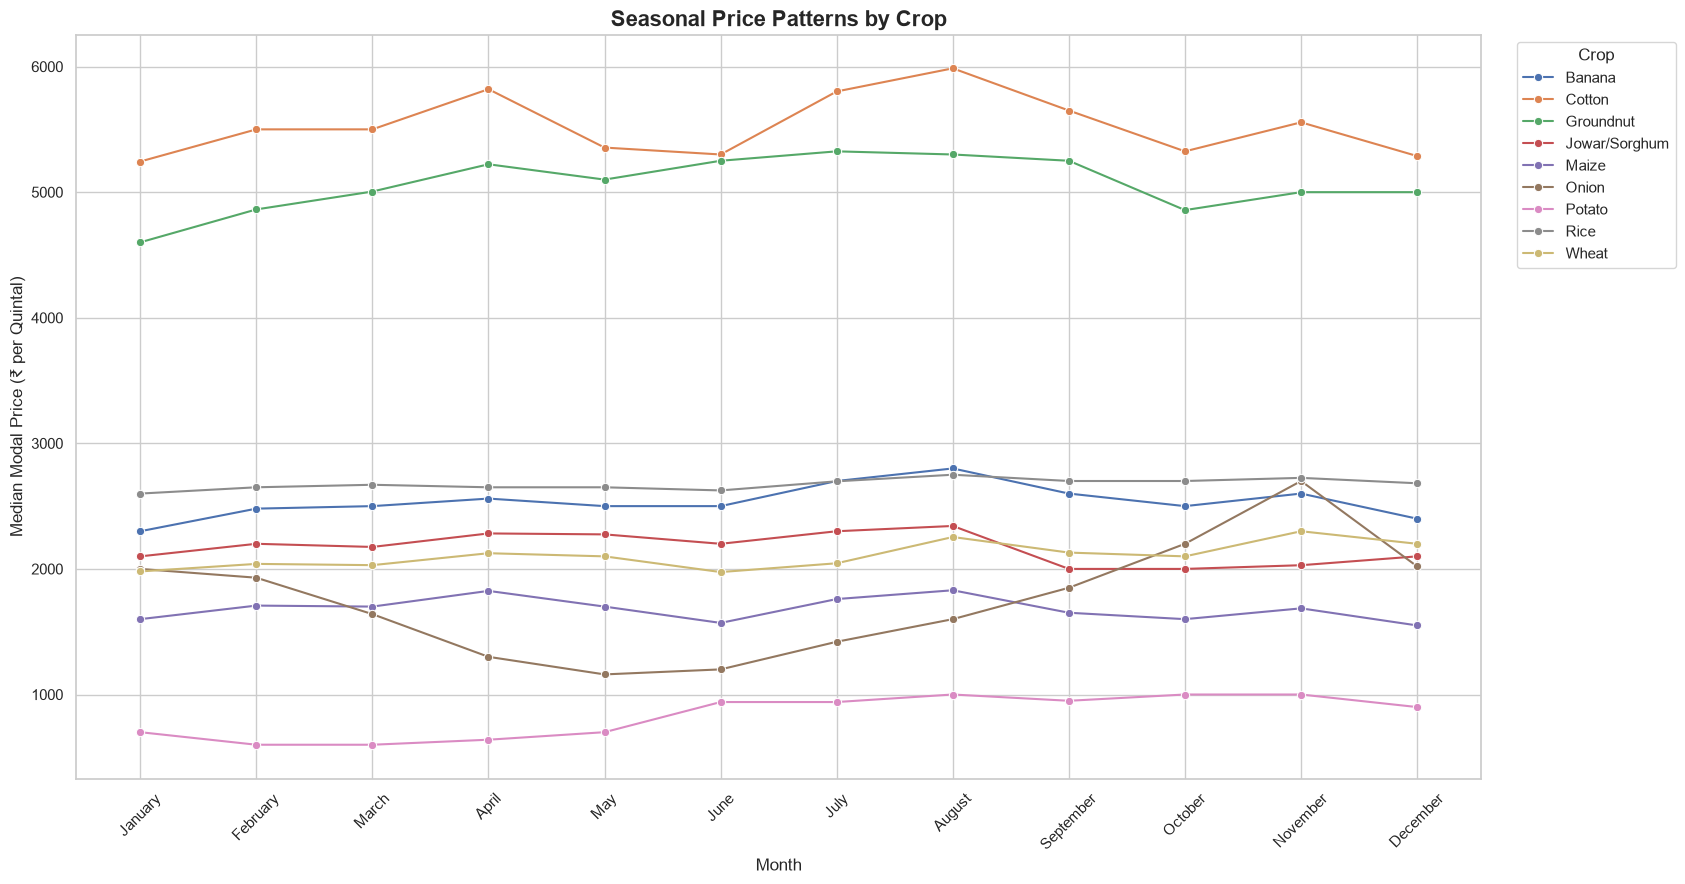


PRICE VOLATILITY BY CROP
                   Mean       Std  Median    Min       Max  Coefficient_of_Variation
Crop                                                                                
Banana         2996.844  3767.220  2500.0    8.0  500000.0                     1.257
Onion          2015.040  1426.681  1600.0    7.0   72000.0                     0.708
Potato          980.620   605.276   800.0    5.0    7000.0                     0.617
Rice           2897.434  1493.342  2675.0    2.0  210000.0                     0.515
Jowar/Sorghum  2363.415   928.022  2185.0  160.5    9000.0                     0.393
Maize          1718.588   483.089  1650.0   30.0   12092.0                     0.281
Groundnut      5192.979  1415.117  5012.0    4.0   14401.0                     0.273
Cotton         5858.601  1576.338  5412.0   54.6   40000.0                     0.269
Wheat          2131.073   443.947  2090.0    1.0    8700.0                     0.208


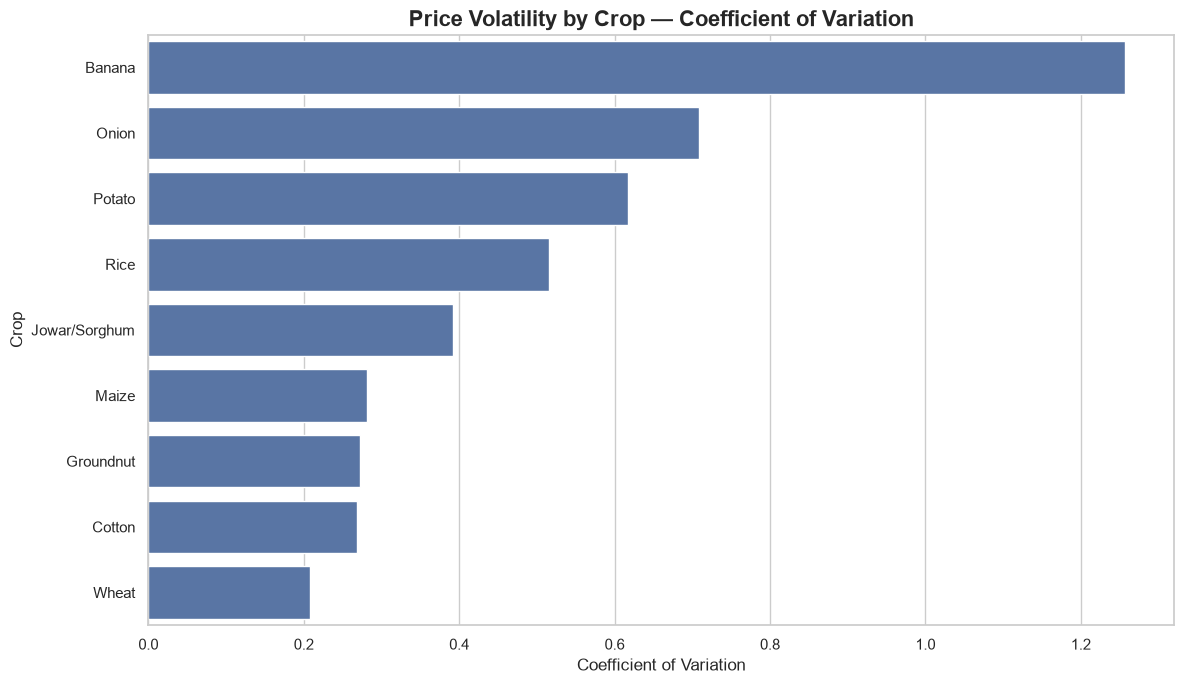

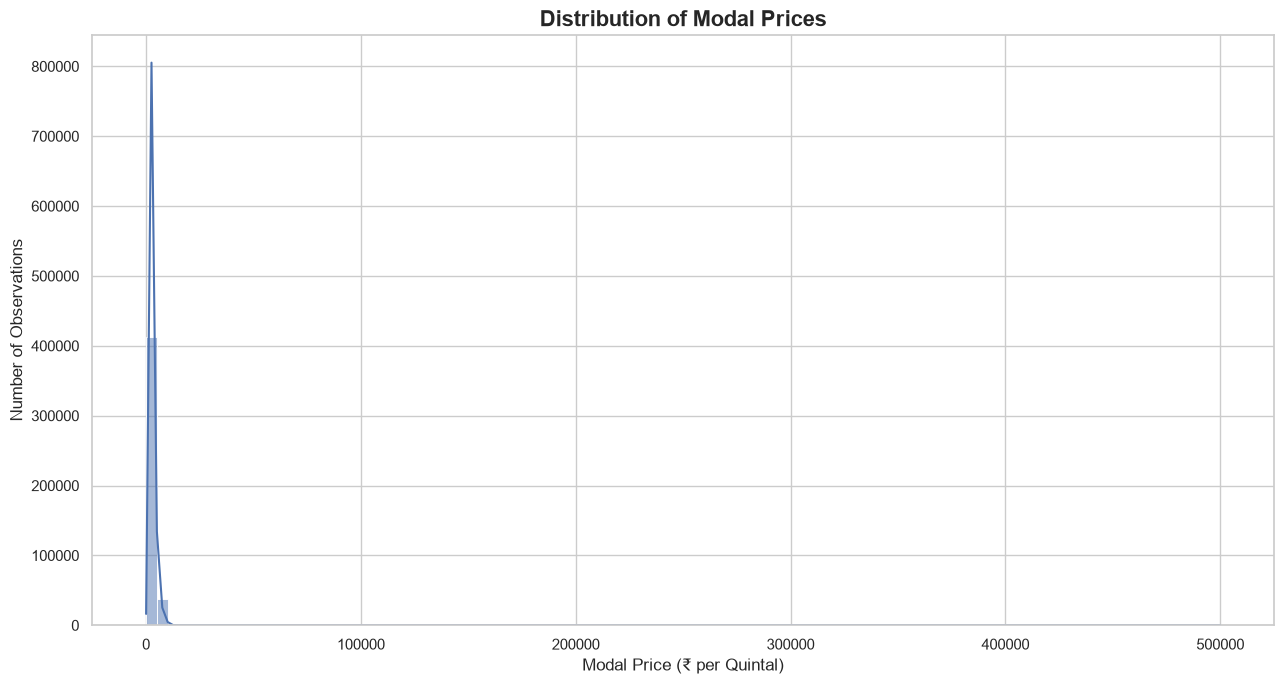

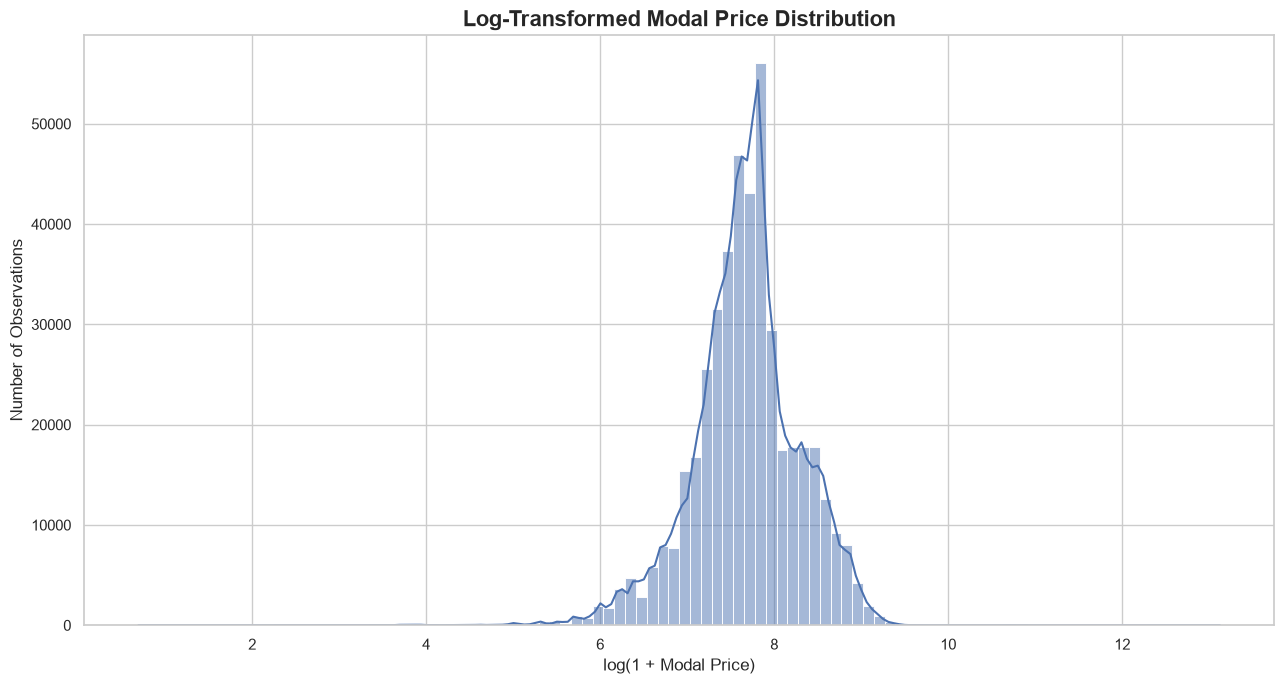


TOP STATES BY OBSERVATION COUNT
                   Observations  Markets  Crops  Median_Price  Mean_Price
State                                                                    
Uttar Pradesh             99958      241      9        2050.0     2043.69
Madhya Pradesh            49142      331      9        1980.0     2169.99
Maharashtra               42571      536      9        2000.0     2436.71
Keralam                   41579      278      6        3400.0     3666.81
Gujarat                   33344      213      9        2625.0     3323.13
West Bengal               29941       77      7        2500.0     2537.86
Rajasthan                 23759      186      9        2050.0     2611.44
Punjab                    23743      223      8        1520.0     1783.51
Karnataka                 19380      148      9        2200.0     2734.96
Haryana                   17548      126      9        1700.0     2098.07
Tamil Nadu                13180      319      7        4984.5     4794.74
Odish

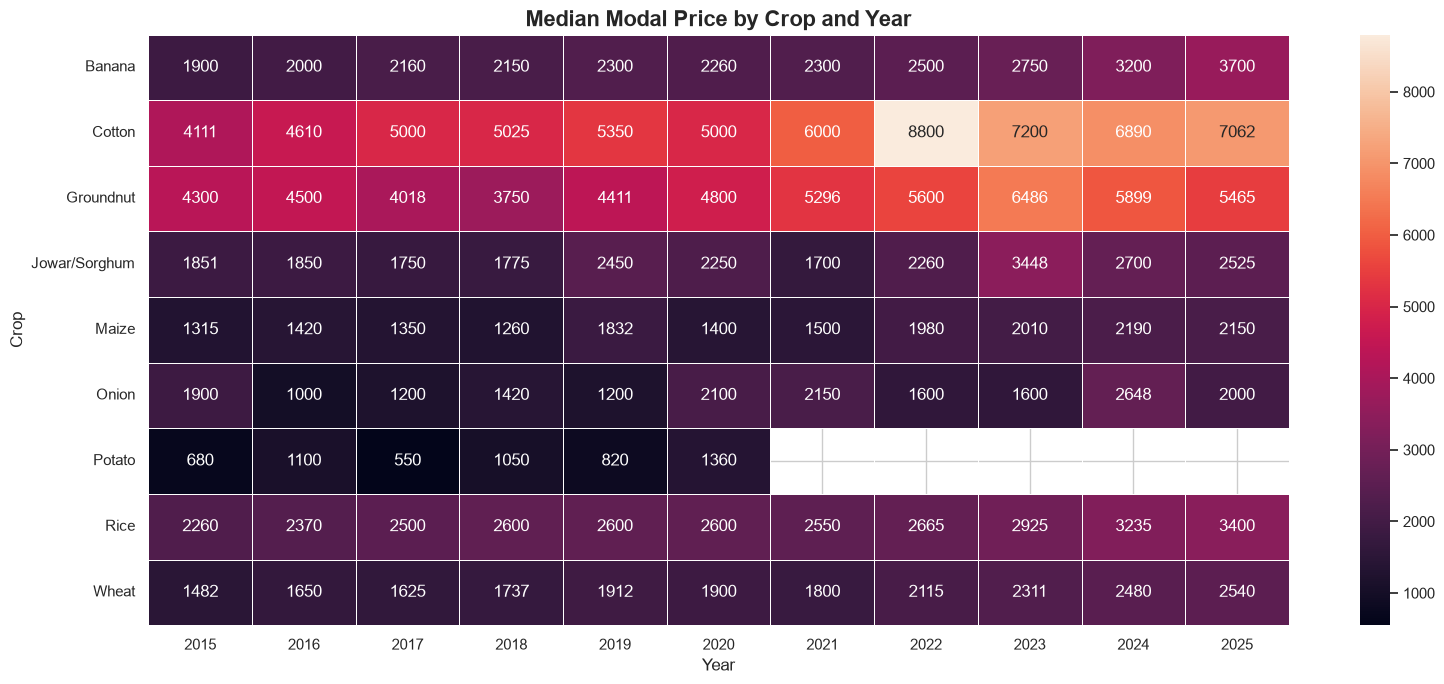

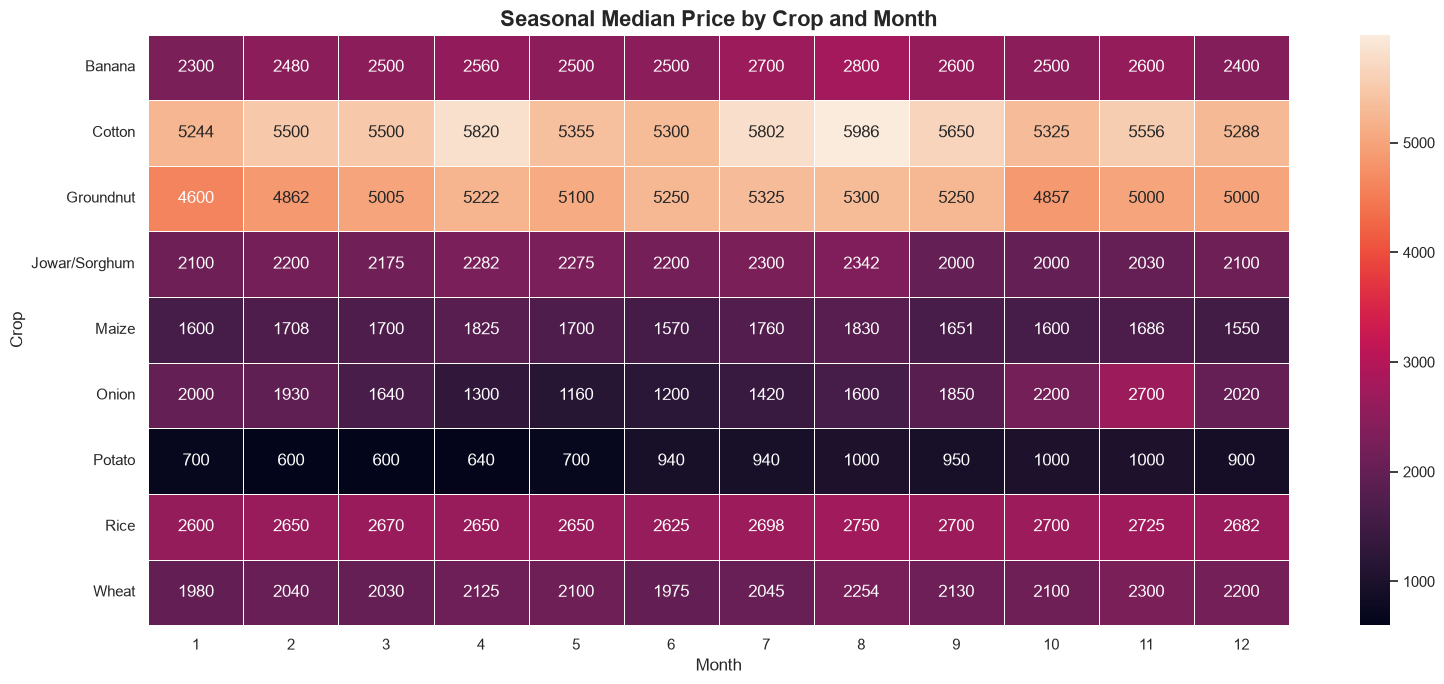


PRICE-RANGE ANOMALY ANALYSIS
Total anomaly observations: 604
Percentage of dataset: 0.1342%

Anomalies by crop:
Crop
Wheat        500
Maize         73
Onion         23
Groundnut      8

Anomalies by year:
Year
2024    604

Anomaly direction:
Anomaly_Direction
Above Maximum    337
Below Minimum    267

EXTREME PRICE CHECK
Threshold: ₹10,000
Observations >= threshold: 854

Extreme observations by crop:
Crop
Cotton       330
Banana       203
Groundnut    161
Onion        120
Rice          37
Maize          3

Extreme observations by year:
Year
2015      2
2016      8
2017     29
2018      6
2019     16
2020     40
2021     29
2022    384
2023    145
2024     78
2025    117

MONTHLY COVERAGE CHECK
Total months: 132
Months with zero observations: 0
Lowest monthly observation count: 979
Highest monthly observation count: 4,995

EDA COMPLETE
Dataset observations analyzed: 450,008
Crops analyzed:               9
States analyzed:              32
Markets analyzed:             3398
Date range:  

In [1]:
# ============================================================
# FOOD PRICE FORECASTING
# 03 - EXPLORATORY DATA ANALYSIS
# ============================================================

import sys
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# ============================================================
# 1. PROJECT PATHS
# ============================================================

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

DATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "agmarknet_cleaned_observations.csv"
)

OUTPUT_DIR = PROJECT_ROOT / "outputs" / "eda"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


# ============================================================
# 2. DISPLAY SETTINGS
# ============================================================

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)
pd.set_option("display.max_rows", 100)

sns.set_theme(style="whitegrid")


print("=" * 90)
print("FOOD PRICE FORECASTING — EXPLORATORY DATA ANALYSIS")
print("=" * 90)


# ============================================================
# 3. LOAD DATA
# ============================================================

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Cleaned dataset not found:\n{DATA_PATH}"
    )

df = pd.read_csv(DATA_PATH)

df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

print("\nDATASET LOADED")
print("-" * 90)
print(f"Path:       {DATA_PATH}")
print(f"Rows:       {len(df):,}")
print(f"Columns:    {len(df.columns)}")
print(f"Date range: {df['Date'].min().date()} → {df['Date'].max().date()}")


# ============================================================
# 4. BASIC VALIDATION
# ============================================================

expected_columns = [
    "Date",
    "Crop",
    "Commodity ID",
    "Commodity Group ID",
    "State",
    "State ID",
    "Market",
    "Market ID",
    "Variety",
    "Grade",
    "Minimum Price",
    "Maximum Price",
    "Modal Price",
    "Unit",
    "Price_Range_Anomaly",
]

missing_columns = [
    col for col in expected_columns
    if col not in df.columns
]

if missing_columns:
    raise ValueError(
        f"Missing expected columns: {missing_columns}"
    )

observation_key = [
    "Date",
    "Crop",
    "State ID",
    "Market ID",
    "Variety",
    "Grade",
]

print("\nBASIC VALIDATION")
print("-" * 90)
print(f"Missing expected columns: {missing_columns}")
print(f"Exact duplicate rows:      {df.duplicated().sum():,}")
print(
    f"Duplicate observation keys: "
    f"{df.duplicated(subset=observation_key).sum():,}"
)

print("\nMissing values:")
print(df.isna().sum())


# ============================================================
# 5. DATASET OVERVIEW
# ============================================================

print("\n" + "=" * 90)
print("DATASET OVERVIEW")
print("=" * 90)

print("\nUnique values:")
print(f"Dates:       {df['Date'].nunique():,}")
print(f"Crops:       {df['Crop'].nunique():,}")
print(f"States:      {df['State'].nunique():,}")
print(f"Markets:     {df['Market'].nunique():,}")
print(f"Varieties:   {df['Variety'].nunique():,}")
print(f"Grades:      {df['Grade'].nunique():,}")

print("\nCrops:")
print(sorted(df["Crop"].dropna().unique()))

print("\nPrice statistics:")
print(
    df[
        ["Minimum Price", "Maximum Price", "Modal Price"]
    ].describe().round(2)
)


# ============================================================
# 6. CROP-LEVEL SUMMARY
# ============================================================

crop_summary = (
    df.groupby("Crop")
    .agg(
        Observations=("Modal Price", "count"),
        Markets=("Market", "nunique"),
        States=("State", "nunique"),
        First_Date=("Date", "min"),
        Last_Date=("Date", "max"),
        Median_Price=("Modal Price", "median"),
        Mean_Price=("Modal Price", "mean"),
        Min_Price=("Modal Price", "min"),
        Max_Price=("Modal Price", "max"),
        Std_Price=("Modal Price", "std"),
    )
    .sort_values("Observations", ascending=False)
)

print("\n" + "=" * 90)
print("CROP-LEVEL SUMMARY")
print("=" * 90)

print(crop_summary.round(2))


# ============================================================
# 7. CREATE TIME FEATURES
# ============================================================

df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Month_Name"] = df["Date"].dt.month_name()
df["Year_Month"] = df["Date"].dt.to_period("M").astype(str)


# ============================================================
# 8. YEARLY SUMMARY
# ============================================================

yearly_summary = (
    df.groupby("Year")
    .agg(
        Observations=("Modal Price", "count"),
        Crops=("Crop", "nunique"),
        Markets=("Market", "nunique"),
        States=("State", "nunique"),
        Median_Price=("Modal Price", "median"),
        Mean_Price=("Modal Price", "mean"),
        Min_Price=("Modal Price", "min"),
        Max_Price=("Modal Price", "max"),
    )
)

print("\n" + "=" * 90)
print("YEARLY SUMMARY")
print("=" * 90)

print(yearly_summary.round(2))


# ============================================================
# 9. MONTHLY SUMMARY
# ============================================================

monthly_summary = (
    df.groupby("Year_Month")
    .agg(
        Observations=("Modal Price", "count"),
        Median_Price=("Modal Price", "median"),
        Mean_Price=("Modal Price", "mean"),
    )
)

print("\n" + "=" * 90)
print("MONTHLY SUMMARY — FIRST 20 MONTHS")
print("=" * 90)

print(monthly_summary.head(20).round(2))


# ============================================================
# 10. EXTREME PRICE ANALYSIS
# ============================================================

print("\n" + "=" * 90)
print("EXTREME PRICE ANALYSIS")
print("=" * 90)

print("\nHighest Modal Price observations:")

highest_prices = (
    df[
        [
            "Date",
            "Crop",
            "State",
            "Market",
            "Variety",
            "Grade",
            "Minimum Price",
            "Maximum Price",
            "Modal Price",
        ]
    ]
    .sort_values("Modal Price", ascending=False)
    .head(20)
)

print(highest_prices.to_string(index=False))


print("\nLowest Modal Price observations:")

lowest_prices = (
    df[
        [
            "Date",
            "Crop",
            "State",
            "Market",
            "Variety",
            "Grade",
            "Minimum Price",
            "Maximum Price",
            "Modal Price",
        ]
    ]
    .sort_values("Modal Price", ascending=True)
    .head(20)
)

print(lowest_prices.to_string(index=False))


# ============================================================
# 11. TOP 1% PRICE THRESHOLD
# ============================================================

price_99 = df["Modal Price"].quantile(0.99)

top_1_percent = df[
    df["Modal Price"] >= price_99
].copy()

print("\n" + "=" * 90)
print("TOP 1% PRICE ANALYSIS")
print("=" * 90)

print(f"99th percentile price: ₹{price_99:,.2f}")
print(f"Observations in top 1%: {len(top_1_percent):,}")

print("\nTop 1% observations by crop:")
print(
    top_1_percent["Crop"]
    .value_counts()
    .to_string()
)


# ============================================================
# 12. CROP PRICE DISTRIBUTION
# ============================================================

plt.figure(figsize=(14, 7))

sns.boxplot(
    data=df,
    x="Crop",
    y="Modal Price"
)

plt.title(
    "Food Commodity Price Distribution by Crop",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Crop")
plt.ylabel("Modal Price (₹ per Quintal)")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "01_crop_price_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 13. CROP MEDIAN PRICE COMPARISON
# ============================================================

crop_median = (
    df.groupby("Crop")["Modal Price"]
    .median()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12, 7))

sns.barplot(
    x=crop_median.values,
    y=crop_median.index
)

plt.title(
    "Median Modal Price by Crop",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Median Modal Price (₹ per Quintal)")
plt.ylabel("Crop")

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "02_median_price_by_crop.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 14. OVERALL MONTHLY PRICE TREND
# ============================================================

overall_monthly = (
    df.groupby("Year_Month")["Modal Price"]
    .median()
    .reset_index()
)

overall_monthly["Date"] = pd.to_datetime(
    overall_monthly["Year_Month"]
)

plt.figure(figsize=(16, 7))

plt.plot(
    overall_monthly["Date"],
    overall_monthly["Modal Price"],
    linewidth=2
)

plt.title(
    "Overall Monthly Median Food Price Trend",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Date")
plt.ylabel("Median Modal Price (₹ per Quintal)")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "03_overall_monthly_price_trend.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 15. CROP-WISE MONTHLY PRICE TRENDS
# ============================================================

crop_monthly = (
    df.groupby(["Year_Month", "Crop"])["Modal Price"]
    .median()
    .reset_index()
)

crop_monthly["Date"] = pd.to_datetime(
    crop_monthly["Year_Month"]
)

plt.figure(figsize=(18, 9))

for crop in sorted(crop_monthly["Crop"].unique()):

    crop_data = crop_monthly[
        crop_monthly["Crop"] == crop
    ]

    plt.plot(
        crop_data["Date"],
        crop_data["Modal Price"],
        linewidth=1.7,
        label=crop
    )

plt.title(
    "Monthly Median Price Trends by Crop",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Date")
plt.ylabel("Median Modal Price (₹ per Quintal)")

plt.legend(
    title="Crop",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "04_crop_monthly_price_trends.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 16. YEARLY MEDIAN PRICE BY CROP
# ============================================================

year_crop = (
    df.groupby(["Year", "Crop"])["Modal Price"]
    .median()
    .reset_index()
)

plt.figure(figsize=(16, 8))

sns.lineplot(
    data=year_crop,
    x="Year",
    y="Modal Price",
    hue="Crop",
    marker="o"
)

plt.title(
    "Yearly Median Price Trends by Crop",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Year")
plt.ylabel("Median Modal Price (₹ per Quintal)")

plt.legend(
    title="Crop",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "05_yearly_crop_price_trends.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 17. SEASONAL MONTHLY PATTERNS
# ============================================================

seasonal_monthly = (
    df.groupby(["Month", "Month_Name", "Crop"])["Modal Price"]
    .median()
    .reset_index()
)

month_order = [
    "January",
    "February",
    "March",
    "April",
    "May",
    "June",
    "July",
    "August",
    "September",
    "October",
    "November",
    "December",
]

seasonal_monthly["Month_Name"] = pd.Categorical(
    seasonal_monthly["Month_Name"],
    categories=month_order,
    ordered=True
)

seasonal_overall = (
    df.groupby(["Month", "Month_Name"])["Modal Price"]
    .median()
    .reset_index()
)

seasonal_overall["Month_Name"] = pd.Categorical(
    seasonal_overall["Month_Name"],
    categories=month_order,
    ordered=True
)

seasonal_overall = seasonal_overall.sort_values("Month")


plt.figure(figsize=(14, 7))

sns.lineplot(
    data=seasonal_overall,
    x="Month_Name",
    y="Modal Price",
    marker="o",
    linewidth=2.5
)

plt.title(
    "Seasonal Monthly Price Pattern",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Month")
plt.ylabel("Median Modal Price (₹ per Quintal)")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "06_seasonal_monthly_pattern.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 18. SEASONAL PATTERN BY CROP
# ============================================================

plt.figure(figsize=(17, 9))

sns.lineplot(
    data=seasonal_monthly,
    x="Month_Name",
    y="Modal Price",
    hue="Crop",
    marker="o"
)

plt.title(
    "Seasonal Price Patterns by Crop",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Month")
plt.ylabel("Median Modal Price (₹ per Quintal)")

plt.xticks(rotation=45)

plt.legend(
    title="Crop",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "07_seasonal_patterns_by_crop.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 19. PRICE VOLATILITY BY CROP
# ============================================================

volatility_summary = (
    df.groupby("Crop")["Modal Price"]
    .agg(
        Mean="mean",
        Std="std",
        Median="median",
        Min="min",
        Max="max"
    )
)

volatility_summary["Coefficient_of_Variation"] = (
    volatility_summary["Std"]
    / volatility_summary["Mean"]
)

volatility_summary = volatility_summary.sort_values(
    "Coefficient_of_Variation",
    ascending=False
)

print("\n" + "=" * 90)
print("PRICE VOLATILITY BY CROP")
print("=" * 90)

print(
    volatility_summary.round(3)
)


plt.figure(figsize=(12, 7))

sns.barplot(
    x=volatility_summary["Coefficient_of_Variation"],
    y=volatility_summary.index
)

plt.title(
    "Price Volatility by Crop — Coefficient of Variation",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Coefficient of Variation")
plt.ylabel("Crop")

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "08_price_volatility_by_crop.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 20. PRICE DISTRIBUTION
# ============================================================

plt.figure(figsize=(13, 7))

sns.histplot(
    df["Modal Price"],
    bins=100,
    kde=True
)

plt.title(
    "Distribution of Modal Prices",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Modal Price (₹ per Quintal)")
plt.ylabel("Number of Observations")

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "09_modal_price_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 21. LOG-TRANSFORMED PRICE DISTRIBUTION
# ============================================================

df["Log_Modal_Price"] = np.log1p(
    df["Modal Price"]
)

plt.figure(figsize=(13, 7))

sns.histplot(
    df["Log_Modal_Price"],
    bins=100,
    kde=True
)

plt.title(
    "Log-Transformed Modal Price Distribution",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("log(1 + Modal Price)")
plt.ylabel("Number of Observations")

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "10_log_modal_price_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 22. STATE-LEVEL ANALYSIS
# ============================================================

state_summary = (
    df.groupby("State")
    .agg(
        Observations=("Modal Price", "count"),
        Markets=("Market", "nunique"),
        Crops=("Crop", "nunique"),
        Median_Price=("Modal Price", "median"),
        Mean_Price=("Modal Price", "mean"),
    )
    .sort_values("Observations", ascending=False)
)

print("\n" + "=" * 90)
print("TOP STATES BY OBSERVATION COUNT")
print("=" * 90)

print(state_summary.head(20).round(2))


# ============================================================
# 23. TOP MARKETS BY OBSERVATION COUNT
# ============================================================

market_summary = (
    df.groupby(["State", "Market"])
    .agg(
        Observations=("Modal Price", "count"),
        Crops=("Crop", "nunique"),
        Median_Price=("Modal Price", "median"),
        Mean_Price=("Modal Price", "mean"),
    )
    .sort_values("Observations", ascending=False)
)

print("\n" + "=" * 90)
print("TOP 20 MARKETS BY OBSERVATION COUNT")
print("=" * 90)

print(
    market_summary.head(20).round(2)
)


# ============================================================
# 24. CROP × YEAR HEATMAP
# ============================================================

crop_year_median = (
    df.groupby(["Crop", "Year"])["Modal Price"]
    .median()
    .unstack()
)

plt.figure(figsize=(16, 7))

sns.heatmap(
    crop_year_median,
    annot=True,
    fmt=".0f",
    linewidths=0.5
)

plt.title(
    "Median Modal Price by Crop and Year",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Year")
plt.ylabel("Crop")

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "11_crop_year_price_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 25. CROP × MONTH SEASONAL HEATMAP
# ============================================================

crop_month_median = (
    df.groupby(["Crop", "Month"])["Modal Price"]
    .median()
    .unstack()
)

crop_month_median = crop_month_median.reindex(
    columns=range(1, 13)
)

plt.figure(figsize=(16, 7))

sns.heatmap(
    crop_month_median,
    annot=True,
    fmt=".0f",
    linewidths=0.5
)

plt.title(
    "Seasonal Median Price by Crop and Month",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Month")
plt.ylabel("Crop")

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "12_crop_month_seasonal_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 26. PRICE-RANGE ANOMALY ANALYSIS
# ============================================================

anomaly_df = df[
    df["Price_Range_Anomaly"] == True
].copy()

print("\n" + "=" * 90)
print("PRICE-RANGE ANOMALY ANALYSIS")
print("=" * 90)

print(f"Total anomaly observations: {len(anomaly_df):,}")
print(
    f"Percentage of dataset: "
    f"{len(anomaly_df) / len(df) * 100:.4f}%"
)

if len(anomaly_df) > 0:

    print("\nAnomalies by crop:")
    print(
        anomaly_df["Crop"]
        .value_counts()
        .to_string()
    )

    print("\nAnomalies by year:")
    print(
        anomaly_df["Year"]
        .value_counts()
        .sort_index()
        .to_string()
    )

    print("\nAnomaly direction:")

    anomaly_df["Anomaly_Direction"] = np.select(
        [
            anomaly_df["Modal Price"] < anomaly_df["Minimum Price"],
            anomaly_df["Modal Price"] > anomaly_df["Maximum Price"],
        ],
        [
            "Below Minimum",
            "Above Maximum",
        ],
        default="Other"
    )

    print(
        anomaly_df["Anomaly_Direction"]
        .value_counts()
        .to_string()
    )


# ============================================================
# 27. EXTREME PRICE CHECK
# ============================================================

extreme_threshold = 10000

extreme_prices = df[
    df["Modal Price"] >= extreme_threshold
].copy()

print("\n" + "=" * 90)
print("EXTREME PRICE CHECK")
print("=" * 90)

print(
    f"Threshold: ₹{extreme_threshold:,}"
)

print(
    f"Observations >= threshold: "
    f"{len(extreme_prices):,}"
)

if len(extreme_prices) > 0:

    print("\nExtreme observations by crop:")
    print(
        extreme_prices["Crop"]
        .value_counts()
        .to_string()
    )

    print("\nExtreme observations by year:")
    print(
        extreme_prices["Year"]
        .value_counts()
        .sort_index()
        .to_string()
    )


# ============================================================
# 28. MONTHLY OBSERVATION COVERAGE
# ============================================================

monthly_coverage = (
    df.groupby("Year_Month")
    .agg(
        Observations=("Modal Price", "count"),
        Crops=("Crop", "nunique"),
        Markets=("Market", "nunique"),
        States=("State", "nunique"),
    )
)

print("\n" + "=" * 90)
print("MONTHLY COVERAGE CHECK")
print("=" * 90)

print(
    f"Total months: {len(monthly_coverage):,}"
)

print(
    f"Months with zero observations: "
    f"{(monthly_coverage['Observations'] == 0).sum():,}"
)

print(
    f"Lowest monthly observation count: "
    f"{monthly_coverage['Observations'].min():,}"
)

print(
    f"Highest monthly observation count: "
    f"{monthly_coverage['Observations'].max():,}"
)


# ============================================================
# 29. SAVE SUMMARY TABLES
# ============================================================

crop_summary.to_csv(
    OUTPUT_DIR / "crop_summary.csv"
)

yearly_summary.to_csv(
    OUTPUT_DIR / "yearly_summary.csv"
)

monthly_summary.to_csv(
    OUTPUT_DIR / "monthly_summary.csv"
)

volatility_summary.to_csv(
    OUTPUT_DIR / "price_volatility_summary.csv"
)

state_summary.to_csv(
    OUTPUT_DIR / "state_summary.csv"
)

market_summary.to_csv(
    OUTPUT_DIR / "market_summary.csv"
)


# ============================================================
# 30. SAVE EXTREME PRICE OBSERVATIONS
# ============================================================

highest_prices.to_csv(
    OUTPUT_DIR / "highest_price_observations.csv",
    index=False
)

lowest_prices.to_csv(
    OUTPUT_DIR / "lowest_price_observations.csv",
    index=False
)

if len(anomaly_df) > 0:
    anomaly_df.to_csv(
        OUTPUT_DIR / "price_range_anomalies.csv",
        index=False
    )

if len(extreme_prices) > 0:
    extreme_prices.to_csv(
        OUTPUT_DIR / "extreme_price_observations.csv",
        index=False
    )


# ============================================================
# 31. FINAL EDA SUMMARY
# ============================================================

print("\n" + "=" * 90)
print("EDA COMPLETE")
print("=" * 90)

print(f"Dataset observations analyzed: {len(df):,}")
print(f"Crops analyzed:               {df['Crop'].nunique()}")
print(f"States analyzed:              {df['State'].nunique()}")
print(f"Markets analyzed:             {df['Market'].nunique()}")
print(
    f"Date range:                   "
    f"{df['Date'].min().date()} → {df['Date'].max().date()}"
)
print(
    f"Price-range anomalies:        "
    f"{df['Price_Range_Anomaly'].sum():,}"
)
print(
    f"Maximum Modal Price:          "
    f"₹{df['Modal Price'].max():,.2f}"
)

print(f"\nEDA outputs saved to:")
print(OUTPUT_DIR)

print("\nGenerated visualizations:")
for file in sorted(OUTPUT_DIR.glob("*.png")):
    print(f"  ✓ {file.name}")

print("\nGenerated summary files:")
for file in sorted(OUTPUT_DIR.glob("*.csv")):
    print(f"  ✓ {file.name}")

print("\n" + "=" * 90)
print("NEXT STAGE: FEATURE ENGINEERING")
print("=" * 90)

In [2]:
# ============================================================
# EXTREME PRICE INVESTIGATION
# ============================================================

print("=" * 90)
print("EXTREME MODAL PRICE INVESTIGATION")
print("=" * 90)


# ------------------------------------------------------------
# 1. PRICE THRESHOLDS
# ------------------------------------------------------------

thresholds = [5000, 7500, 10000, 20000, 50000, 100000]

print("\nObservations above selected price thresholds:")
print("-" * 90)

for threshold in thresholds:
    count = (df["Modal Price"] >= threshold).sum()
    percentage = count / len(df) * 100

    print(
        f"₹{threshold:>7,} and above: "
        f"{count:>7,} observations "
        f"({percentage:.4f}%)"
    )


# ------------------------------------------------------------
# 2. EXTREME OBSERVATIONS BY CROP
# ------------------------------------------------------------

extreme_crop = (
    df[df["Modal Price"] >= 10000]
    .groupby("Crop")
    .agg(
        Observations=("Modal Price", "count"),
        Median_Price=("Modal Price", "median"),
        Mean_Price=("Modal Price", "mean"),
        Maximum_Price=("Modal Price", "max")
    )
    .sort_values("Observations", ascending=False)
)

print("\n" + "=" * 90)
print("OBSERVATIONS ≥ ₹10,000 BY CROP")
print("=" * 90)

print(extreme_crop.round(2))


# ------------------------------------------------------------
# 3. EXTREME OBSERVATIONS BY STATE
# ------------------------------------------------------------

extreme_state = (
    df[df["Modal Price"] >= 10000]
    .groupby("State")
    .agg(
        Observations=("Modal Price", "count"),
        Crops=("Crop", "nunique"),
        Markets=("Market", "nunique"),
        Maximum_Price=("Modal Price", "max")
    )
    .sort_values("Observations", ascending=False)
)

print("\n" + "=" * 90)
print("OBSERVATIONS ≥ ₹10,000 BY STATE")
print("=" * 90)

print(extreme_state.head(20).round(2))


# ------------------------------------------------------------
# 4. EXTREME OBSERVATIONS BY MARKET
# ------------------------------------------------------------

extreme_market = (
    df[df["Modal Price"] >= 10000]
    .groupby(["State", "Market", "Crop"])
    .agg(
        Observations=("Modal Price", "count"),
        Maximum_Price=("Modal Price", "max"),
        Median_Price=("Modal Price", "median")
    )
    .sort_values(
        ["Observations", "Maximum_Price"],
        ascending=False
    )
)

print("\n" + "=" * 90)
print("TOP MARKET/CROP COMBINATIONS WITH PRICES ≥ ₹10,000")
print("=" * 90)

print(
    extreme_market
    .head(30)
    .round(2)
)


# ------------------------------------------------------------
# 5. EXTREME OBSERVATIONS BY YEAR
# ------------------------------------------------------------

extreme_year = (
    df[df["Modal Price"] >= 10000]
    .groupby("Year")
    .agg(
        Observations=("Modal Price", "count"),
        Maximum_Price=("Modal Price", "max"),
        Median_Price=("Modal Price", "median")
    )
    .sort_index()
)

print("\n" + "=" * 90)
print("OBSERVATIONS ≥ ₹10,000 BY YEAR")
print("=" * 90)

print(extreme_year.round(2))


# ------------------------------------------------------------
# 6. INVESTIGATE THE ₹100,000+ OBSERVATIONS
# ------------------------------------------------------------

very_extreme = (
    df[df["Modal Price"] >= 100000]
    [
        [
            "Date",
            "Crop",
            "State",
            "Market",
            "Variety",
            "Grade",
            "Minimum Price",
            "Maximum Price",
            "Modal Price",
            "Unit"
        ]
    ]
    .sort_values("Modal Price", ascending=False)
)

print("\n" + "=" * 90)
print("VERY EXTREME OBSERVATIONS — ₹100,000+")
print("=" * 90)

print(
    f"Number of observations: {len(very_extreme):,}"
)

if len(very_extreme) > 0:
    print(
        very_extreme.to_string(index=False)
    )
else:
    print("No observations found.")


# ------------------------------------------------------------
# 7. CHECK WHETHER EXTREME VALUES ARE CONSISTENT
#    WITH THEIR MINIMUM/MAXIMUM PRICE RANGE
# ------------------------------------------------------------

if len(very_extreme) > 0:

    print("\n" + "=" * 90)
    print("EXTREME VALUE RANGE CONSISTENCY")
    print("=" * 90)

    extreme_range_check = very_extreme.copy()

    extreme_range_check["Within_Range"] = (
        extreme_range_check["Minimum Price"].isna()
        | extreme_range_check["Maximum Price"].isna()
        | (
            (extreme_range_check["Modal Price"] >= extreme_range_check["Minimum Price"])
            & (extreme_range_check["Modal Price"] <= extreme_range_check["Maximum Price"])
        )
    )

    print(
        extreme_range_check[
            [
                "Crop",
                "State",
                "Market",
                "Minimum Price",
                "Maximum Price",
                "Modal Price",
                "Within_Range"
            ]
        ].to_string(index=False)
    )


# ------------------------------------------------------------
# 8. SAVE EXTREME INVESTIGATION
# ------------------------------------------------------------

extreme_investigation_path = (
    OUTPUT_DIR / "extreme_price_investigation.csv"
)

df[
    df["Modal Price"] >= 10000
].sort_values(
    "Modal Price",
    ascending=False
).to_csv(
    extreme_investigation_path,
    index=False
)


print("\n" + "=" * 90)
print("EXTREME PRICE INVESTIGATION COMPLETE")
print("=" * 90)

print(
    f"Saved: {extreme_investigation_path}"
)

EXTREME MODAL PRICE INVESTIGATION

Observations above selected price thresholds:
------------------------------------------------------------------------------------------
₹  5,000 and above:  41,616 observations (9.2478%)
₹  7,500 and above:   6,834 observations (1.5186%)
₹ 10,000 and above:     854 observations (0.1898%)
₹ 20,000 and above:      76 observations (0.0169%)
₹ 50,000 and above:      20 observations (0.0044%)
₹100,000 and above:       7 observations (0.0016%)

OBSERVATIONS ≥ ₹10,000 BY CROP
           Observations  Median_Price  Mean_Price  Maximum_Price
Crop                                                            
Cotton              330       10500.0    10921.43        40000.0
Banana              203       10675.0    26015.12       500000.0
Groundnut           161       10620.0    10783.05        14401.0
Onion               120       11700.0    16508.53        72000.0
Rice                 37       12350.0    24653.05       210000.0
Maize                 3       10400

In [3]:
# ============================================================
# EXTREME PRICE PERSISTENCE ANALYSIS
# ============================================================

print("=" * 90)
print("EXTREME PRICE PERSISTENCE ANALYSIS")
print("=" * 90)


# ------------------------------------------------------------
# 1. CREATE PRICE BANDS
# ------------------------------------------------------------

df["Price_Band"] = pd.cut(
    df["Modal Price"],
    bins=[
        0,
        2000,
        5000,
        7500,
        10000,
        20000,
        50000,
        100000,
        np.inf
    ],
    labels=[
        "< ₹2,000",
        "₹2,000–₹5,000",
        "₹5,000–₹7,500",
        "₹7,500–₹10,000",
        "₹10,000–₹20,000",
        "₹20,000–₹50,000",
        "₹50,000–₹100,000",
        "≥ ₹100,000"
    ],
    include_lowest=True
)


print("\nPRICE BAND DISTRIBUTION")
print("-" * 90)

price_band_summary = (
    df["Price_Band"]
    .value_counts()
    .sort_index()
)

price_band_percentage = (
    price_band_summary
    / len(df)
    * 100
)

price_band_table = pd.DataFrame({
    "Observations": price_band_summary,
    "Percentage": price_band_percentage
})

print(price_band_table.round(4))


# ------------------------------------------------------------
# 2. EXTREME OBSERVATIONS BY CROP + MARKET + VARIETY
# ------------------------------------------------------------

extreme = df[
    df["Modal Price"] >= 10000
].copy()

persistence = (
    extreme
    .groupby(
        [
            "Crop",
            "State",
            "Market",
            "Variety",
            "Grade"
        ]
    )
    .agg(
        Extreme_Observations=("Modal Price", "count"),
        Maximum_Price=("Modal Price", "max"),
        Median_Price=("Modal Price", "median"),
        First_Date=("Date", "min"),
        Last_Date=("Date", "max")
    )
    .sort_values(
        [
            "Extreme_Observations",
            "Maximum_Price"
        ],
        ascending=False
    )
)

print("\n" + "=" * 90)
print("MOST PERSISTENT EXTREME PRICE GROUPS")
print("=" * 90)

print(
    persistence.head(30).round(2)
)


# ------------------------------------------------------------
# 3. CHECK THE VERY EXTREME GROUPS
# ------------------------------------------------------------

very_extreme_groups = (
    df[
        df["Modal Price"] >= 50000
    ]
    .groupby(
        [
            "Crop",
            "State",
            "Market",
            "Variety",
            "Grade"
        ]
    )
    .agg(
        Observations=("Modal Price", "count"),
        Maximum_Price=("Modal Price", "max"),
        Median_Price=("Modal Price", "median"),
        First_Date=("Date", "min"),
        Last_Date=("Date", "max")
    )
    .sort_values(
        "Maximum_Price",
        ascending=False
    )
)

print("\n" + "=" * 90)
print("GROUPS WITH PRICES ≥ ₹50,000")
print("=" * 90)

print(
    very_extreme_groups.round(2)
)


# ------------------------------------------------------------
# 4. COUNT EXTREME RECORDS THAT ARE ISOLATED
# ------------------------------------------------------------

group_sizes = (
    extreme
    .groupby(
        [
            "Crop",
            "State",
            "Market",
            "Variety",
            "Grade"
        ]
    )
    .size()
)

isolated_count = (
    group_sizes[group_sizes == 1]
    .sum()
)

persistent_count = (
    group_sizes[group_sizes > 1]
    .sum()
)

print("\n" + "=" * 90)
print("ISOLATED VS PERSISTENT EXTREME OBSERVATIONS")
print("=" * 90)

print(
    f"Extreme observations (≥ ₹10,000): {len(extreme):,}"
)

print(
    f"Isolated extreme observations:      {isolated_count:,}"
)

print(
    f"Persistent extreme observations:    {persistent_count:,}"
)

print(
    f"Unique extreme groups:              {len(group_sizes):,}"
)

print(
    f"Groups occurring more than once:   "
    f"{(group_sizes > 1).sum():,}"
)


# ------------------------------------------------------------
# 5. EXTREME OBSERVATIONS BY CROP AND PRICE BAND
# ------------------------------------------------------------

extreme_band_crop = pd.crosstab(
    df["Crop"],
    df["Price_Band"]
)

print("\n" + "=" * 90)
print("PRICE BANDS BY CROP")
print("=" * 90)

print(
    extreme_band_crop.to_string()
)


# ------------------------------------------------------------
# 6. SAVE RESULTS
# ------------------------------------------------------------

price_band_table.to_csv(
    OUTPUT_DIR / "price_band_summary.csv"
)

persistence.to_csv(
    OUTPUT_DIR / "extreme_price_persistence.csv"
)

very_extreme_groups.to_csv(
    OUTPUT_DIR / "very_extreme_groups.csv"
)

extreme_band_crop.to_csv(
    OUTPUT_DIR / "crop_price_band_distribution.csv"
)


# ------------------------------------------------------------
# 7. COMPLETION
# ------------------------------------------------------------

print("\n" + "=" * 90)
print("PERSISTENCE ANALYSIS COMPLETE")
print("=" * 90)

print(
    "Saved:"
)

print("  ✓ price_band_summary.csv")
print("  ✓ extreme_price_persistence.csv")
print("  ✓ very_extreme_groups.csv")
print("  ✓ crop_price_band_distribution.csv")

EXTREME PRICE PERSISTENCE ANALYSIS

PRICE BAND DISTRIBUTION
------------------------------------------------------------------------------------------
                  Observations  Percentage
Price_Band                                
< ₹2,000                197010     43.7792
₹2,000–₹5,000           215238     47.8298
₹5,000–₹7,500            31461      6.9912
₹7,500–₹10,000            5625      1.2500
₹10,000–₹20,000            598      0.1329
₹20,000–₹50,000             56      0.0124
₹50,000–₹100,000            13      0.0029
≥ ₹100,000                   7      0.0016

MOST PERSISTENT EXTREME PRICE GROUPS
                                                                                               Extreme_Observations  Maximum_Price  Median_Price First_Date  \
Crop      State       Market                                           Variety         Grade                                                                  
Groundnut Tamil Nadu  Vellore APMC                             

C:\Users\acer\AppData\Local\Temp\ipykernel_9584\2326549043.py:104: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  persistence.head(30).round(2)
C:\Users\acer\AppData\Local\Temp\ipykernel_9584\2326549043.py:143: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  very_extreme_groups.round(2)
